Proiect Big Data - RECIPE SITE TRAFFIC - problemă de clasificare

*Postolache Andreea Miruna, grupa 405*

# Cuprins

1. [Introducere](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=Bgl0C5_bX_is&line=1&uniqifier=1)

2. [Script-uri Spark pentru procesare, pregătire, curățare, transformare date utilizând Dataframes și Spark SQL.](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=tY3WTKRmeIu1&line=1&uniqifier=1)

3. [Aplicare două metode de ML](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=0WwqBePtfKSv&line=1&uniqifier=1)

    3.1. [Logistic Regression](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=IhzbFsrDxBlx&line=1&uniqifier=1)

    3.2. [Decision Tree Classifier](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=bhnppq_FKdMN&line=4&uniqifier=1)

4. [Pipeline](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=fvJPsxcpg2Jt&line=1&uniqifier=1)

5. [UDF](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=fvJPsxcpg2Jt&line=1&uniqifier=1)

    5.1. [Optimizare hiperparametrii Logistic Regression](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=4Za7E4SFboVP&line=1&uniqifier=1)

    5.2. [Optimizare hiperparametrii Decision Tree Classifier](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=RUepB_qsKiOl&line=1&uniqifier=1)

6. [Aplicarea DL](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=tOSFOsuQnMpw&line=1&uniqifier=1)

7. [Proces de streaming cu Spark Streaming](https://colab.research.google.com/drive/1vTSxSYJ8WSS21iB6ak5h22FeZLBjBW-f#scrollTo=0_Rz6EuP2rI1&line=2&uniqifier=1)


# 1.Introducere

## Prezentarea succintă a setului de date

Setul de date care va fi analizat în cadrul acestui proiect a fost realizat pentru a fi folosit de oameni să se inspire cu privire la ce să gătească cu ingriedentele pe care le au la îndemână.

Astfel, setul de date cuprinde informații, precum:
- numărul de ordin al rețetei
- numărul de calorii pe care îl conține rețeta
- numărul de grame de carbohidrați pe care îl conține rețeta
- numărul de grame de zahăr pe care îl conține rețeta
- numărul de grame de proteine pe care îl conține rețeta
- categoria din care face parte rețeta
- numărul de porții
- influența rețetei asupra traficului la momentul introducerii acesteia


### Structura setului de date
\begin{array}{|c|c|} \hline
Denumire atribut & Detalii \\ \hline
recipe & Numeric,\ ID\ unic\ al\ rețetei  \\
calories & Numeric \\
carbohydrate & Numeric \\
sugar & Numeric  \\
protein & Numeric \\
category & Șir\ de\ caractere. Există\ între 1-10\ categorii\ de\ rețete\ ('Lunch/Snacks','Beverages','Potato', 'Vegetable','Meat','Chicken','Pork','Dessert','Breakfast','One Dish Meal')  \\
servings & Numeric \\
high\_traffic & Șir\ de\ caractere.\ Are\ valoarea\ High\ dacă\ la\ expunerea\ rețetei\ traficul\ este\ mare. \\ \hline
\end{array}


## Enunțarea obiectivelor

În cadrul acestui proiect se dorește să se prezică ce rețetă va aduce un trafic mare. Astfel, aceasta este considerată o problemă de clasificare pentru care se vor folosi două modele Pyspark ML: Logistic Regression și Decision Tree Classifier. La acestea se adaugă și crearea unei rețele neuronale utilizând Tenserflow. În cele din urmă se vor prezice cu cele două modele menționate mai sus, pe baza datelor din stream, rezultatele fiind salvate într-un fișier.

## Setul de date

[Recipe Site Traffic](https://www.kaggle.com/datasets/nourelimane/recipe-site-traffic-2212?select=recipe_site_traffic_2212.csv) este setul de date pe care se va lucra. Acesta este un set de date găsit pe platforma kaggle, dar care original face parte din certificarea „Data Scientist Professional” de pe platforma DataCamp.


# 2. Script-uri Spark pentru procesare, pregătire, curățare, transformare date utilizând Dataframes și Spark SQL.

## Importuri

In [ ]:
!pip install pyspark

In [ ]:
from pyspark import SparkContext as sc
from pyspark.sql import SparkSession
import seaborn as sns
import pandas as pd
from pyspark.sql.types import StructField, IntegerType, StringType, StructType, FloatType
import pyspark.sql.functions as f
from pyspark.sql.functions import round,concat,col,when,regexp_replace
import numpy as np
import matplotlib.pyplot as plt

## Crearea unui obiect SparkSession, urmată de crearea unei scheme proprii și citirea setului de date CSV referitor la traficul generat de rețete.

In [ ]:
spark = SparkSession.builder.appName('project').getOrCreate()

In [ ]:
data_schema = [
    StructField('recipe',IntegerType(),True),
    StructField('calories',FloatType(),True),
    StructField('carbohydrate',FloatType(),True),
    StructField('sugar',FloatType(),True),
    StructField('protein',FloatType(),True),
    StructField('category',StringType(),True),
    StructField('servings',StringType(),True),
    StructField('high_traffic',StringType(),True)
              ]

In [ ]:
schema_struct = StructType(fields = data_schema)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = spark.read.csv('/content/drive/MyDrive/Data/recipe_site_traffic_2212.csv',schema=schema_struct,header=True)

In [ ]:

df.createOrReplaceTempView("recipe_site_traffic")
df = df.withColumn('calories', round(df['calories'], 2))
df = df.withColumn('carbohydrate', round(df['carbohydrate'], 2))
df = df.withColumn('sugar', round(df['sugar'], 2))
df = df.withColumn('protein', round(df['protein'], 2))


In [ ]:
df.show()

+------+--------+------------+-----+-------+--------------+--------+------------+
|recipe|calories|carbohydrate|sugar|protein|      category|servings|high_traffic|
+------+--------+------------+-----+-------+--------------+--------+------------+
|     1|    NULL|        NULL| NULL|   NULL|          Pork|       6|        High|
|     2|   35.48|       38.56| 0.66|   0.92|        Potato|       4|        High|
|     3|  914.28|       42.68| 3.09|   2.88|     Breakfast|       1|          NA|
|     4|   97.03|       30.56|38.63|   0.02|     Beverages|       4|        High|
|     5|   27.05|        1.85|  0.8|   0.53|     Beverages|       4|          NA|
|     6|  691.15|        3.46| 1.65|  53.93| One Dish Meal|       2|        High|
|     7|  183.94|       47.95| 9.75|  46.71|Chicken Breast|       4|          NA|
|     8|  299.14|        3.17|  0.4|   32.4|  Lunch/Snacks|       4|          NA|
|     9|  538.52|        3.78| 3.37|   3.79|          Pork|       6|        High|
|    10|  248.28

Selectarea a primelor 5 linii din setul de date pentru a avea o imagine mai clară asupra setului de date

In [ ]:
shema_first_5 = spark.sql("SELECT * FROM recipe_site_traffic LIMIT 5")
shema_first_5.show()

+------+--------+------------+-----+-------+---------+--------+------------+
|recipe|calories|carbohydrate|sugar|protein| category|servings|high_traffic|
+------+--------+------------+-----+-------+---------+--------+------------+
|     1|    NULL|        NULL| NULL|   NULL|     Pork|       6|        High|
|     2|   35.48|       38.56| 0.66|   0.92|   Potato|       4|        High|
|     3|  914.28|       42.68| 3.09|   2.88|Breakfast|       1|          NA|
|     4|   97.03|       30.56|38.63|   0.02|Beverages|       4|        High|
|     5|   27.05|        1.85|  0.8|   0.53|Beverages|       4|          NA|
+------+--------+------------+-----+-------+---------+--------+------------+



## Vizualizarea tipurilor de date

In [ ]:
df.printSchema()

root
 |-- recipe: integer (nullable = true)
 |-- calories: float (nullable = true)
 |-- carbohydrate: float (nullable = true)
 |-- sugar: float (nullable = true)
 |-- protein: float (nullable = true)
 |-- category: string (nullable = true)
 |-- servings: string (nullable = true)
 |-- high_traffic: string (nullable = true)



Vizualizarea mai multor detalii despre setul de date în ceea ce privește distribuția datelor

In [ ]:
df.describe().show()

+-------+-----------------+------------------+------------------+-----------------+-----------------+---------+------------------+------------+
|summary|           recipe|          calories|      carbohydrate|            sugar|          protein| category|          servings|high_traffic|
+-------+-----------------+------------------+------------------+-----------------+-----------------+---------+------------------+------------+
|  count|              947|               895|               895|              895|              895|      947|               947|         947|
|   mean|            474.0| 435.9391960410599|35.069675937338666|9.046547495590408|24.14929610864785|     NULL|3.4735169491525424|        NULL|
| stddev|273.5196519447917|453.02099808361174|43.949031767437724| 14.6791758108222|36.36973852674482|     NULL|1.7333782423947894|        NULL|
|    min|                1|              0.14|              0.03|             0.01|              0.0|Beverages|                 1|      

Mai jos se va realiza validarea datelor pentru fiecare coloană din setul de date

1. Recipe

Datele din această coloană au tipul de date corect, find un identificator unic (prin lipsa duplicatelor) și, de asemenea, nu are valori lipsă.

In [ ]:
# Verificare data type
df.select('recipe').printSchema()

# Verificare unicitate
recipe_unique = spark.sql("SELECT COUNT(DISTINCT recipe) AS recipe_count FROM recipe_site_traffic")

recipe_count = recipe_unique.collect()[0]['recipe_count']

if recipe_count == df.count():
    print('It is unique identifier')
else:
    print('It has duplicates')

# Verificare număr valori lipsă
print('Missing values number:', df.filter(col('recipe').isNull()).count())

root
 |-- recipe: integer (nullable = true)

It is unique identifier
Missing values number: 0


2. Calories

Datele din acestă coloană au tipul de date corect, având 52 de valori lipsă.

In [ ]:
# Verificare data type
df.select('calories').printSchema()

# Verificare număr valori lipsă
print('Missing values number:', df.filter(col('calories').isNull()).count())

root
 |-- calories: float (nullable = true)

Missing values number: 52


3. Carbohydrate

Datele din acestă coloană au tipul de date corect, având 52 de valori lipsă.

In [ ]:
# Verificare data type
df.select('carbohydrate').printSchema()

# Verificare număr valori lipsă
df_null_values_number_carbo = spark.sql("SELECT COUNT(*) AS null_count FROM recipe_site_traffic WHERE carbohydrate IS NULL")
null_values_number_carbo = df_null_values_number_carbo.collect()[0]['null_count']
print('Missing values number:', null_values_number_carbo )

root
 |-- carbohydrate: float (nullable = true)

Missing values number: 52


4. Sugar

Datele din acestă coloană au tipul de date corect, având 52 de valori lipsă.

In [ ]:
# Verificare data type
df.select('sugar').printSchema()

# Verificare număr valori lipsă
print('Missing values number:', df.filter(col('sugar').isNull()).count())

root
 |-- sugar: float (nullable = true)

Missing values number: 52


5. Protein

Datele din acestă coloană au tipul de date corect, având 52 de valori lipsă.

In [ ]:
# Verificare data type
df.select('protein').printSchema()

# Verificare număr valori lipsă
print('Missing values number:', df.filter(col('protein').isNull()).count())

root
 |-- protein: float (nullable = true)

Missing values number: 52


Se poate observa că coloanele: calories, carbohydrate, sugar și protein respectă tipul de date și au același număr de valori lipsă = 52.
De asemenea, se poate observa că numărul de duplicate (inclusiv prima apariție) corespunde momentului în care toate coloanele au valoarea null.

In [ ]:

subset_columns = ['calories', 'carbohydrate', 'sugar', 'protein']
lines_with_just_one_appearance = df.selectExpr(
  '*',
  'count(*) over (partition by calories, carbohydrate, sugar, protein) as nr'
).filter(f.col('nr') == 1).drop('nr').count()

#Verificare număr de duplicare din setul de date
duplicates_rows_specific_columns= df.count() - lines_with_just_one_appearance
print('Number of duplicate rows for subset columns:', duplicates_rows_specific_columns)

# Verificare număr de linii care au toate valorile null pentru subsetul de coloane
null_values_subset_columns = df.filter((col('calories').isNull()) &
                                   (col('carbohydrate').isNull()) &
                                   (col('sugar').isNull()) &
                                   (col('protein').isNull())).count()
print('Number of duplicate values when all subset columns are null:', null_values_subset_columns)

Number of duplicate rows for subset columns: 52
Number of duplicate values when all subset columns are null: 52


6. Category

Datele din acestă coloană au tipul de date corect, neavând valori lipsă, dar se observă că numărul categoriilor este de 11, în loc de 10, din cauza categoriei 'Chicken Breast'

In [ ]:
df.select('category').printSchema()
print('number of categories: ', df.select('category').distinct().count())

existing_categories = ['Lunch/Snacks', 'Beverages', 'Potato', 'Vegetable', 'Meat', 'Chicken', 'Pork', 'Dessert', 'Breakfast', 'One Dish Meal']
new_categories = spark.sql("SELECT distinct(category) FROM recipe_site_traffic where category not in ('Lunch/Snacks', 'Beverages', 'Potato', 'Vegetable', 'Meat', 'Chicken', 'Pork', 'Dessert', 'Breakfast', 'One Dish Meal')")
new_categories_values = new_categories.select(f.collect_list('category')).first()[0]
print('New categories:', new_categories_values)

print('Missing values number:', df.filter(col('category')==('NA')).count())

root
 |-- category: string (nullable = true)

number of categories:  11
New categories: ['Chicken Breast']
Missing values number: 0


7. Servings

Datele din această coloană ar trebui să fie de tipul numeric, dar există două valori care nu sunt numerice, anume: '6 as a snack' și '4 as a snack', neexistând valori lipsă.

In [ ]:
df.select('servings').printSchema()
print('servings unique values', df.select('servings').distinct().count())
df.select('servings').distinct().show()

root
 |-- servings: string (nullable = true)

servings unique values 6
+------------+
|    servings|
+------------+
|           6|
|6 as a snack|
|           1|
|4 as a snack|
|           4|
|           2|
+------------+



8. High Traffic

Datele din această coloană au tipul corect, dar exisă valori lipsă.

In [ ]:
df.select('high_traffic').printSchema()
df.select('high_traffic').distinct().show()
print('Missing values number: ', df.filter(col('high_traffic')==('NA')).count())

root
 |-- high_traffic: string (nullable = true)

+------------+
|high_traffic|
+------------+
|        High|
|          NA|
+------------+

Missing values number:  373


## Curățarea setului de date

S-a observat mai sus, în partea de vizualizare a datelor, existența a 52 de linii care sunt duplicate și care coincid ca număr cu cele 52 de linii unde valoarile coloanelor: calories, carbohydrate, sugar, protein sunt Null. Se va verifica procentul de date care va fi eliminat și se va decide dacă datele se vor șterge sau nu.

In [ ]:
procent = np.round((52 * 100)/df.count(),3)
print(procent)

5.491


Cum procentul este unul mic, se va alege ștergerea liniilor cu valoarea Null pe cele 4 coloane menționate mai sus.

In [ ]:
df = df.na.drop(subset= subset_columns)
df.count()

895

In [ ]:
print('Number of missing values after drop:', df.filter(col('calories').isNull()).count())
print('Number of missing values after drop:', df.filter(col('carbohydrate').isNull()).count())
print('Number of missing values after drop:', df.filter(col('sugar').isNull()).count())
print('Number of missing values after drop:', df.filter(col('protein').isNull()).count())

Number of missing values after drop: 0
Number of missing values after drop: 0
Number of missing values after drop: 0
Number of missing values after drop: 0


În ceea ce privește categoriile, se va modifica valoarea categoriei în plus din 'Chicken Breast' în categoria 'Chicken', fiind asemănătoare ca nume.

In [ ]:
df = df.withColumn('category', when(df.category.endswith(' Breast'),regexp_replace(df.category,' Breast','')).otherwise(df.category))
df.createOrReplaceTempView("recipe_site_traffic_actual")

#Verificare daca Data Frame s-a schimbat
new_categories = spark.sql("SELECT distinct(category) FROM recipe_site_traffic_actual where category not in ('Lunch/Snacks', 'Beverages', 'Potato', 'Vegetable', 'Meat', 'Chicken', 'Pork', 'Dessert', 'Breakfast', 'One Dish Meal')")
new_categories_values = new_categories.select(f.collect_list('category')).first()[0]
print('New categories:', new_categories_values)

New categories: []


In [ ]:
df.show()

+------+--------+------------+-----+-------+-------------+--------+------------+
|recipe|calories|carbohydrate|sugar|protein|     category|servings|high_traffic|
+------+--------+------------+-----+-------+-------------+--------+------------+
|     2|   35.48|       38.56| 0.66|   0.92|       Potato|       4|        High|
|     3|  914.28|       42.68| 3.09|   2.88|    Breakfast|       1|          NA|
|     4|   97.03|       30.56|38.63|   0.02|    Beverages|       4|        High|
|     5|   27.05|        1.85|  0.8|   0.53|    Beverages|       4|          NA|
|     6|  691.15|        3.46| 1.65|  53.93|One Dish Meal|       2|        High|
|     7|  183.94|       47.95| 9.75|  46.71|      Chicken|       4|          NA|
|     8|  299.14|        3.17|  0.4|   32.4| Lunch/Snacks|       4|          NA|
|     9|  538.52|        3.78| 3.37|   3.79|         Pork|       6|        High|
|    10|  248.28|       48.54| 3.99| 113.85|      Chicken|       2|          NA|
|    11|  170.12|       17.6

In [ ]:
#Verificare dacă numărul categoriilor este cel bun
print('number of categories: ', df.select('category').distinct().count())
df.select('category').distinct().show()

number of categories:  10
+-------------+
|     category|
+-------------+
|    Vegetable|
| Lunch/Snacks|
|      Chicken|
|         Meat|
|       Potato|
|    Breakfast|
|    Beverages|
|      Dessert|
|         Pork|
|One Dish Meal|
+-------------+



În cazul datelor din coloana 'servings' se vor transforma valorile non-numerice în echivalentul numeric.

In [ ]:
df = df.withColumn('servings', when(df.servings.endswith(' as a snack'),regexp_replace(df.servings,' as a snack','')).otherwise(df.servings))


In [ ]:
df.select('servings').distinct().show()

+--------+
|servings|
+--------+
|       6|
|       1|
|       4|
|       2|
+--------+



In [ ]:
df = df.withColumn('servings', col('servings').cast('int'))

In [ ]:
df.select('servings').printSchema()

root
 |-- servings: integer (nullable = true)



În ceea ce privesc valorile din coloana 'high_traffic' se va schimba valoarea din 'NA' în 'Low' pentru o mai bună reprezentare a datelor care nu au un trafic înalt.

In [ ]:
df = df.withColumn('high_traffic', when(df.high_traffic.endswith('NA'),regexp_replace(df.high_traffic,'NA','Low')).otherwise(df.high_traffic))

In [ ]:
df.select('high_traffic').distinct().show()

+------------+
|high_traffic|
+------------+
|        High|
|         Low|
+------------+



Setul de date final obținut în urma validării și curățării datelor

In [ ]:
df.createOrReplaceTempView("recipe_site_traffic_final")
final_data = spark.sql("SELECT * FROM recipe_site_traffic_final")
final_data.show()
final_data.count() #numărul de date rămase

+------+--------+------------+-----+-------+-------------+--------+------------+
|recipe|calories|carbohydrate|sugar|protein|     category|servings|high_traffic|
+------+--------+------------+-----+-------+-------------+--------+------------+
|     2|   35.48|       38.56| 0.66|   0.92|       Potato|       4|        High|
|     3|  914.28|       42.68| 3.09|   2.88|    Breakfast|       1|         Low|
|     4|   97.03|       30.56|38.63|   0.02|    Beverages|       4|        High|
|     5|   27.05|        1.85|  0.8|   0.53|    Beverages|       4|         Low|
|     6|  691.15|        3.46| 1.65|  53.93|One Dish Meal|       2|        High|
|     7|  183.94|       47.95| 9.75|  46.71|      Chicken|       4|         Low|
|     8|  299.14|        3.17|  0.4|   32.4| Lunch/Snacks|       4|         Low|
|     9|  538.52|        3.78| 3.37|   3.79|         Pork|       6|        High|
|    10|  248.28|       48.54| 3.99| 113.85|      Chicken|       2|         Low|
|    11|  170.12|       17.6

895

## Vizualizarea datelor

Pentru a putea realiza grafice pe baza setului de date este necesară conversia în Pandas

In [ ]:
df_final_data = final_data.toPandas()

## Studierea relației dintre nutrienți și numărul de porții

Se utilizează un grafic de tipul „Pairplot” și unul de tipul „Correlogram” pentru studierea relației dintre variabilele menționate. În urma analizei celor două grafice, care oferă același mesaj, se observă faptul că nu este o corelație vizibilă între valorile asociate nutrienților și cele ale porțiilor.

În prima vizualizare, se poate observa în diagramele de dispersie unde sunt reprezentate relațiile dintre doi nutrienți că datele care au aceleași valori privind porțiile nu au o distribuție anume, fiind amplasate fără a se descopri un tipar anume, ceea ce sugerează lipsa unei corelații între nutrienți și porții.

 Acest fapt este vizibil și în cea de-a doua diagramă prin prezența unui coeficient scăzut de corelare între porții și cei patru nutrienți (având valori sub 0).

 În același timp, se poate remarca faptul că informațiile nutriționale nu depind între ele, așa cum este observat prin valorile apropiate de 0 a coeficientului de corelare.

 Astfel, valorile datelor corespunzătoare coloanei 'servings' nu depind și nici nu au o influență asupra caloriilor, carbohidraților, zahărului sau proteinelor.

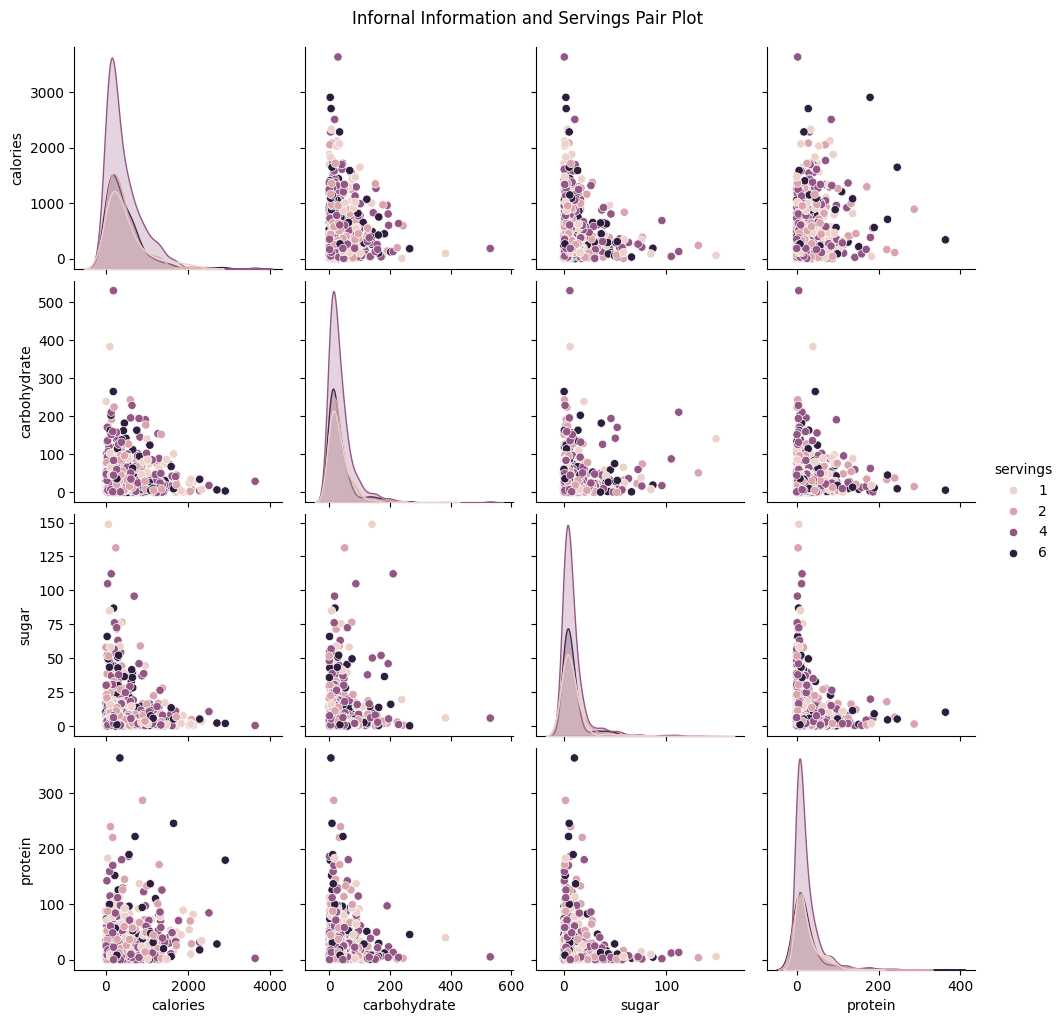

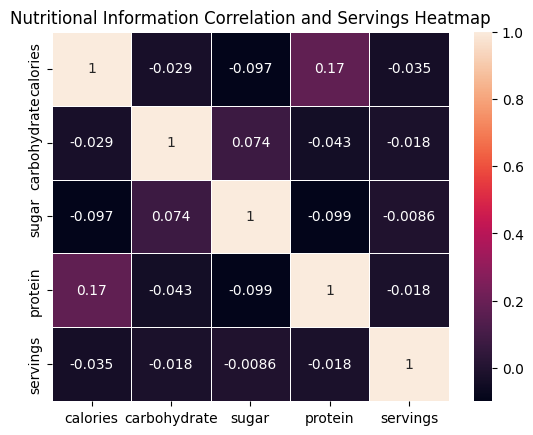

In [ ]:
nutitional_data = spark.sql("SELECT calories, carbohydrate, sugar, protein, servings FROM recipe_site_traffic_final")
df_nutritional_data = nutitional_data.toPandas()

sns.pairplot(df_nutritional_data, hue='servings')
plt.suptitle('Infornal Information and Servings Pair Plot', y=1.02)
plt.show()
# matricea de corelație este creată și utilizată în graficul heatmap
corr = df_nutritional_data.corr()
sns.heatmap(corr, annot=True,linewidth=.5)
plt.title('Nutritional Information Correlation and Servings Heatmap')
plt.show()

În cele ce urmează s-a dorit să se analizeze valorile medii ale informațiilor nutriționale pentru categoria care are cel mai mare număr de valori înalte ale traficului și pentru care numărul porțiilor este de 6.

În urma analizei graficului se poate observa că media valorilor caloriilor este cu mult mai mare decât cele ale celorlalte informații nutriționale.



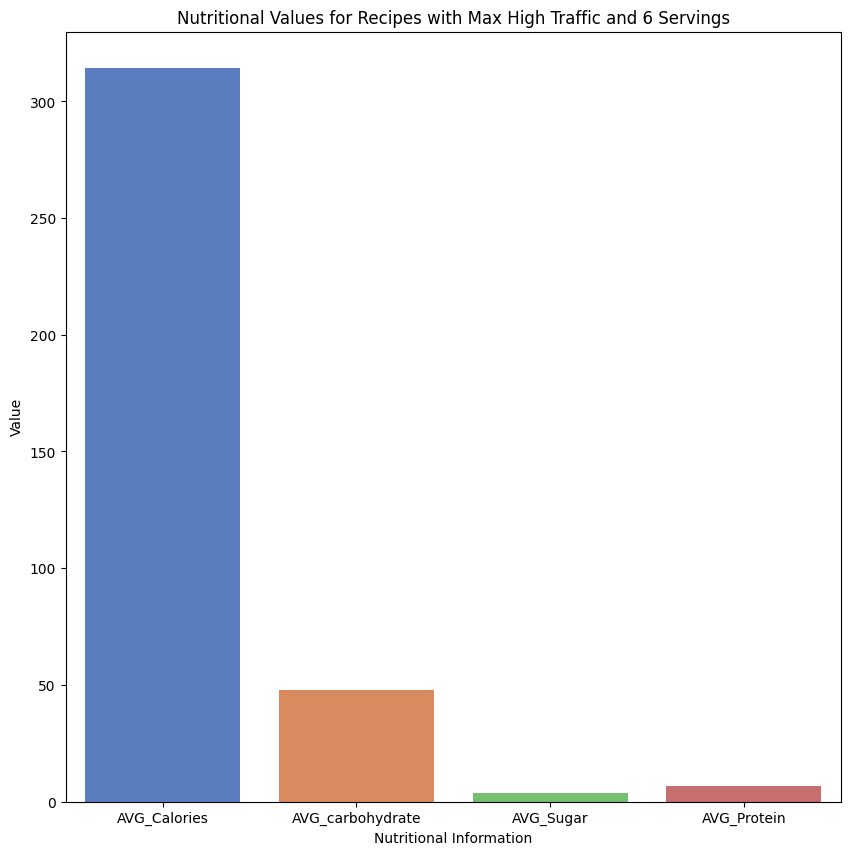

In [ ]:
nutrients_max_traffic_high_category_query = """
WITH subquery AS (
    SELECT category, COUNT(*) AS high_traffic_count
    FROM recipe_site_traffic_final
    WHERE servings = 6 AND high_traffic = 'High'
    GROUP BY category
)
SELECT avg(calories) AVG_Calories ,avg(carbohydrate) AVG_carbohydrate,avg(sugar) AVG_Sugar,avg(protein) AVG_Protein
FROM subquery
JOIN recipe_site_traffic_final ON recipe_site_traffic_final.category = subquery.category
WHERE servings = 6 AND high_traffic = 'High' AND high_traffic_count = (SELECT MAX(high_traffic_count) FROM subquery)
"""
nutrients_max_traffic_high_category = spark.sql(nutrients_max_traffic_high_category_query)

# Convertire în Pandas pentru a putea face graficul
df_nutrients_max_traffic_high_category = nutrients_max_traffic_high_category.toPandas()

plt.figure(figsize=(10, 10))
sns.barplot(data=df_nutrients_max_traffic_high_category, palette='muted')

plt.title('Nutritional Values for Recipes with Max High Traffic and 6 Servings')
plt.xlabel('Nutritional Information')
plt.ylabel('Value')
plt.show()

Pentru a vedea care este numărul rețetelor care generează un trafic mare, s-a ales crearea unui „countplot”. Din interpretarea acestui grafic rezultă că mai mult de 500 de rețete generează un trafic mare, ceea ce înseamnă că mai mult de jumătate din rețete aduc un trafic ridicat.

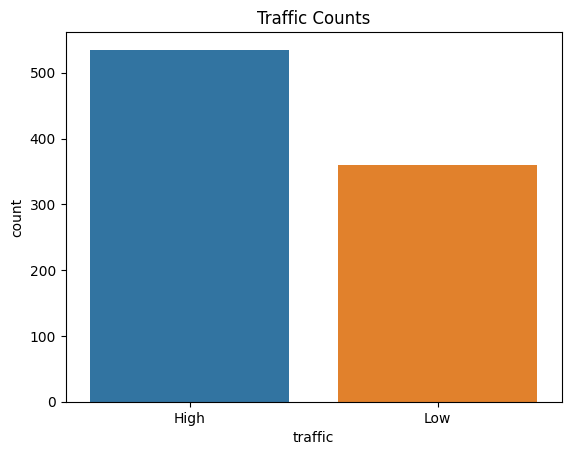

In [ ]:
high_traffic_data = spark.sql("SELECT high_traffic FROM recipe_site_traffic_final")
df_high_traffic = high_traffic_data.toPandas()

sns.countplot(x='high_traffic', data=df_high_traffic, hue='high_traffic')

plt.xlabel('traffic')
plt.ylabel('count')
plt.title('Traffic Counts')

plt.xticks(rotation=0, ha='center')
plt.show()

Pentru analiza particulară a distribuției informațiilor nutriționale se folosesc mai multe tipuri de grafice, dintre care se pot menționa: histograma, „box plot”, grafice de bare.

1. Histograma

În urma analizei histogramelor se poate observa că, în ceea ce privește distribuția, toate au o inclinare pozitivă („right-skewed”), ceea ce presupune că o mare parte a rețetelor tind să aibă valori mai mici pentru factorii nutriționali, mediana valorilor fiind mai mică decât media acestora.

 Mai mult, această distribuție marchează și faptul că există puține rețete care au valori mari pentru toate variabilele nutriționale.

 De asemenea, având acest tip de distribuție, datelor le trebuie aplicat un proces de transformare înainte ca modelul să fie antrenat.

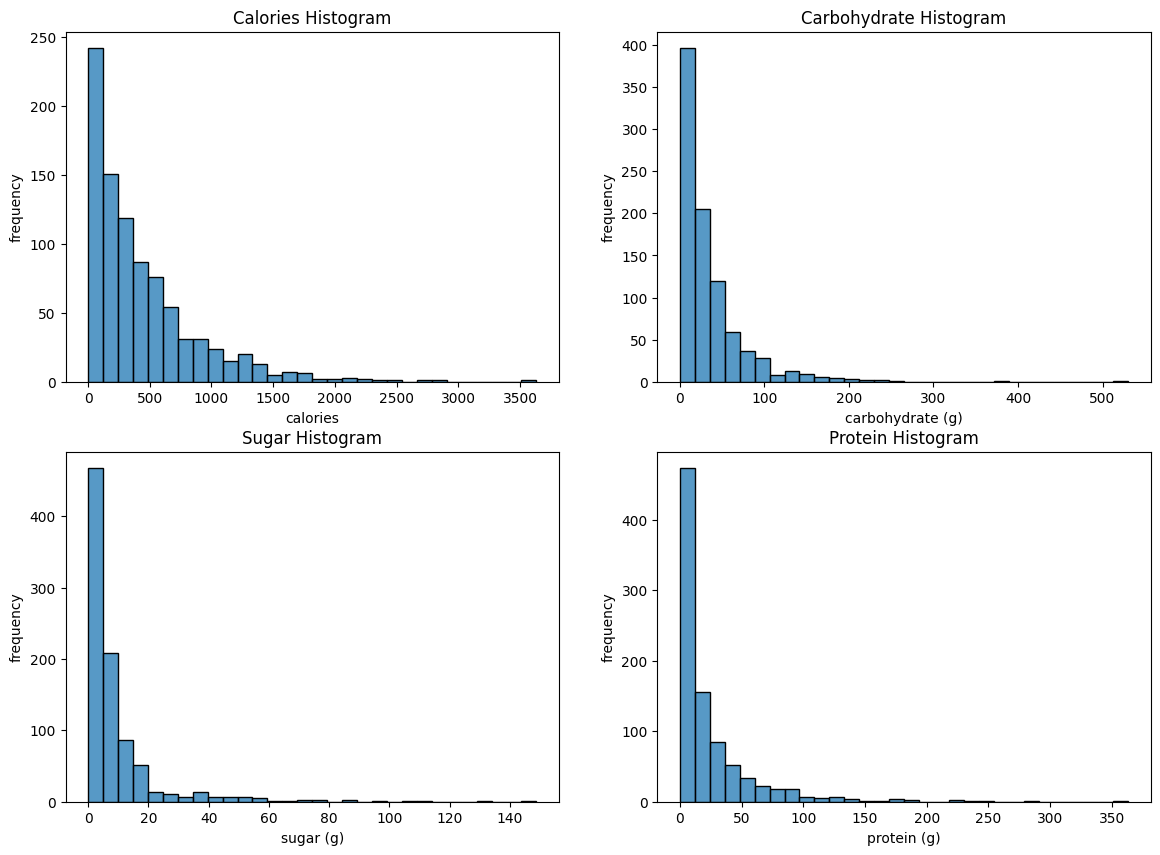

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Calories Histogram
sns.histplot(data=df_final_data, x='calories', bins=30, ax=axs[0, 0])
axs[0, 0].set_title('Calories Histogram')
axs[0, 0].set_xlabel('calories')
axs[0, 0].set_ylabel('frequency')

# Carbohydrate Histogram
sns.histplot(data=df_final_data, x='carbohydrate', bins=30, ax=axs[0, 1])
axs[0, 1].set_title('Carbohydrate Histogram')
axs[0, 1].set_xlabel('carbohydrate (g)')
axs[0, 1].set_ylabel('frequency')

# Sugar Histogram
sns.histplot(data=df_final_data, x='sugar', bins=30, ax=axs[1, 0])
axs[1, 0].set_title('Sugar Histogram')
axs[1, 0].set_xlabel('sugar (g)')
axs[1, 0].set_ylabel('frequency')

# Protein Histogram
sns.histplot(data=df_final_data, x='protein', bins=30, ax=axs[1, 1])
axs[1, 1].set_title('Protein Histogram')
axs[1, 1].set_xlabel('protein (g)')
axs[1, 1].set_ylabel('frequency')


plt.show()

2. Box plot

În urma analizei graficelor s-a observat că în ceea ce privește boxplot-ul caloriilor cutia acestuia este mare, ceea ce înseamnă că are un IQR mai mare, ceea ce presupume că datele centrale variază mai mult.

Mai mult, din studierea bloxpot-ului pentru valorile coloanei 'sugar' se poate observa că are cutia mică, ceea ce înseamnă că are un IQR mic, ceea ce presupune că datele centrale au o variabilitate mai mică, datele centrale fiind mai consistente.

Din aceste observații reiese faptul că cea mai mare variabilitate se găsește în valorile coloanei 'calories' și cea mai mică variabilitate în cele ale coloanei 'sugar'.

De asemenea, în toate aceste diagrame se poate observa prezența punctelor de aberație și că distribuția este „right-sqewed” (așa cum s-a dovedit a fi și în cazul de mai sus), deoarece cuartila superioară și maximul sunt mai departe de mediană decât cuartila inferioară și minimul.

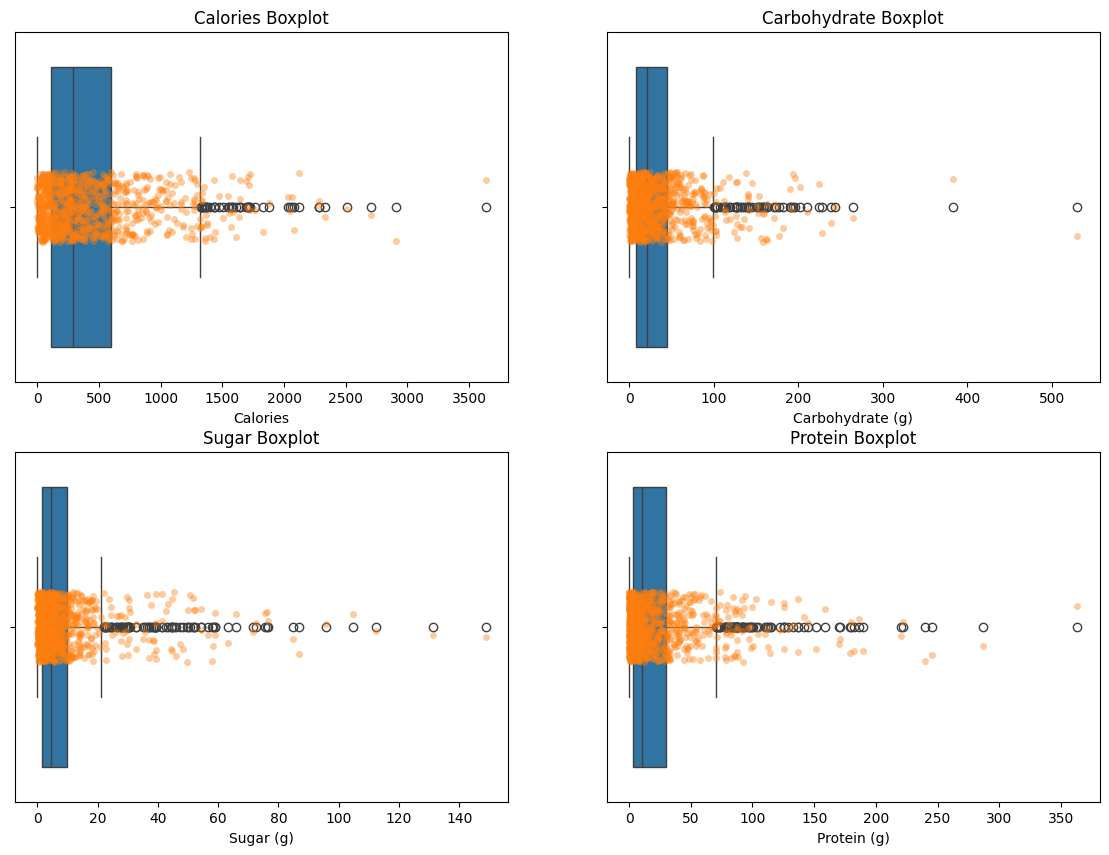

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Calories Boxplot
sns.boxplot(data=df_final_data, x='calories', ax=axs[0, 0])
ax = sns.stripplot(x='calories',data=df_final_data,ax=axs[0, 0],alpha=0.4)
axs[0, 0].set_title('Calories Boxplot')
axs[0, 0].set_xlabel('Calories')

# Carbohydrate Boxplot
sns.boxplot(data=df_final_data, x='carbohydrate', ax=axs[0, 1])
ax = sns.stripplot(x='carbohydrate',data=df_final_data,ax=axs[0, 1],alpha=0.4)
axs[0, 1].set_title('Carbohydrate Boxplot')
axs[0, 1].set_xlabel('Carbohydrate (g)')

# Sugar Boxplot
sns.boxplot(data=df_final_data, x='sugar', ax=axs[1, 0])
ax = sns.stripplot(x='sugar',data=df_final_data,ax=axs[1, 0],alpha=0.4)
axs[1, 0].set_title('Sugar Boxplot')
axs[1, 0].set_xlabel('Sugar (g)')

# Protein Boxplot
sns.boxplot(data=df_final_data, x='protein', ax=axs[1, 1])
ax = sns.stripplot(x='protein',data=df_final_data,ax=axs[1, 1],alpha=0.4)
axs[1, 1].set_title('Protein Boxplot')
axs[1, 1].set_xlabel('Protein (g)')


plt.show()

3. Bar plot

    Pentru a studia valorile de mean ale celor 4 tipuri de informații nutriționale s-au creat grafice cu bare.

    În urma analizei acestora s-a ajuns la următoarele concluzii privind valorile mean: pentru coloana 'calories' depășește cu puțin valoarea de 400, pentru 'carbohydrate' este aproximativ 35, pentru 'sugar' este aproximativ 9, iar pentru coloana 'protein' valoarea ajunge la aproximativ 24.


Text(0.5, 0, 'Protein (g)')

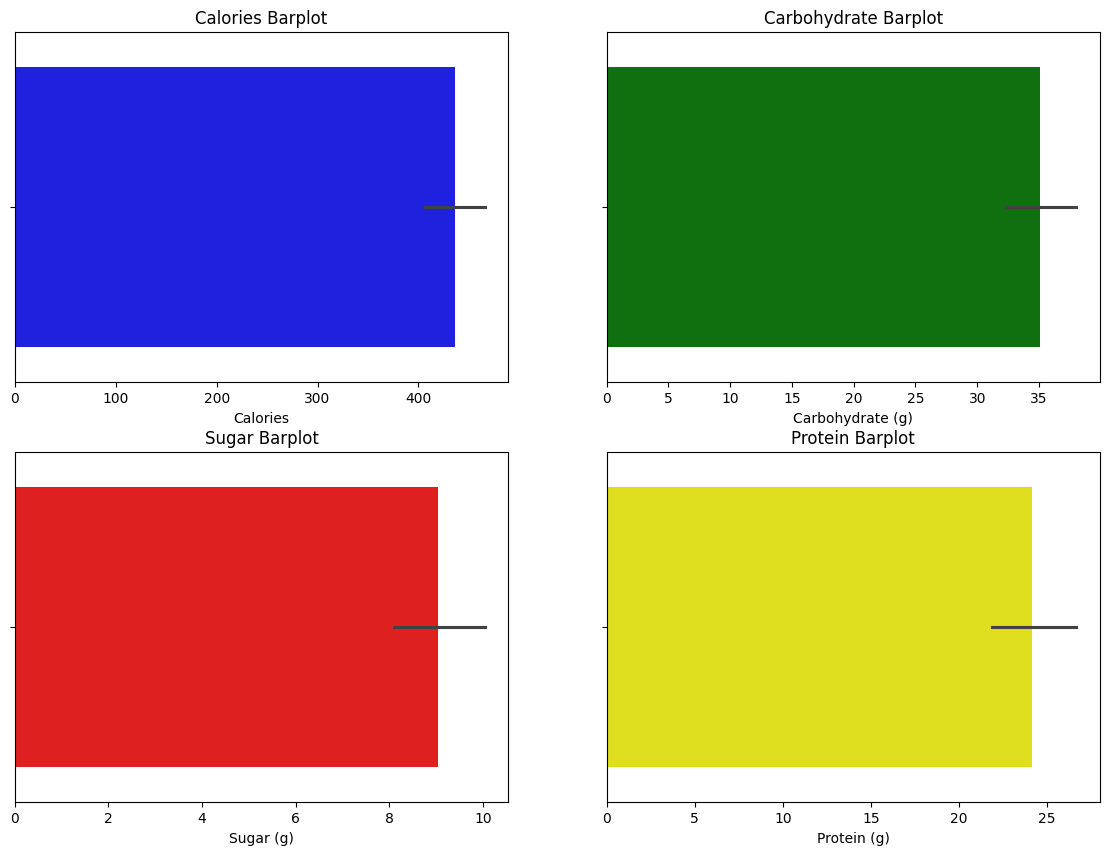

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Calories Barplot
sns.barplot(data=df_final_data, x='calories', ax=axs[0, 0], color='blue')
axs[0, 0].set_title('Calories Barplot')
axs[0, 0].set_xlabel('Calories')

# Carbohydrate Barplot
sns.barplot(data=df_final_data, x='carbohydrate', ax=axs[0, 1],color = 'green')
axs[0, 1].set_title('Carbohydrate Barplot')
axs[0, 1].set_xlabel('Carbohydrate (g)')

# Sugar Barplot
sns.barplot(data=df_final_data, x='sugar', ax=axs[1, 0], color='red')
axs[1, 0].set_title('Sugar Barplot')
axs[1, 0].set_xlabel('Sugar (g)')

# Protein Barplot
sns.barplot(data=df_final_data, x='protein', ax=axs[1, 1], color = 'yellow')
axs[1, 1].set_title('Protein Barplot')
axs[1, 1].set_xlabel('Protein (g)')

Pentru a studia distribuția porțiilor s-a construit o histogramă, în urma analizei căreia s-a observat că valorile au avut cea mai mare concentrație în jurul valorii 4, ceea ce a creat o distribuție disproporționată. Astfel, cea mai comună valoare pentru coloana 'servings' este 4.

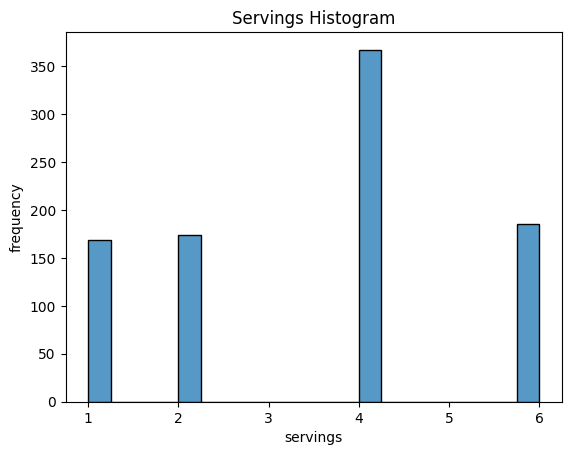

In [ ]:
servings_data = spark.sql("SELECT servings FROM recipe_site_traffic_final")
df_servings_data = servings_data.toPandas()

sns.histplot(data=df_servings_data, x='servings', bins=20)
plt.title('Servings Histogram')
plt.xlabel('servings')
plt.ylabel('frequency')
plt.show()

Pentru studierea distribuției valorilor din coloana 'category' s-a apelat la crearea unui „count plot” care va dezvălui numărul rețetelor din fiecare categorie.

Din analiza graficului, uniformitatea distribuției este întreruptă de valoarea obținută de categoria 'Chicken' care are aproximativ 160 de apariții, fiind cea mai mare valoare. Cea mai mică valoare fiind reprezentată de categoria 'One Dish Meal' care are aproximativ 60 de apariții.

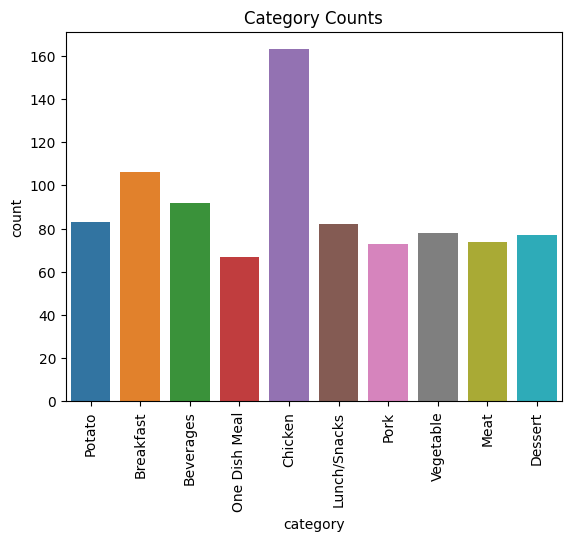

In [ ]:
category_data = spark.sql("SELECT category FROM recipe_site_traffic_final")
df_category_data = category_data.toPandas()

sns.countplot(x='category', data=df_category_data, hue='category', dodge=False)
plt.title('Category Counts')
plt.xlabel('category')
plt.ylabel('count')
plt.xticks(rotation=90, ha='center')
plt.show()

Pentru formarea unei păreri mai clare asupra relației dintre informațiile nutriționale și traficul mare, pentru fiecare tip de element nutrițional se vor compara valorile medii corespunzătoare celor două tipuri de trafic folosindu-se „boxplot”.

În urma analizei graficelor, un aspect general este acela că cutiile elementelor nutriționale au o valoare mediană constantă pentru cele două categorii de trafic. Acest fapt indică ideea că elementele nutriționale ar putea să nu fie unii dintre factorii predominanți care să influențeze traficul.

De asemenea, prezența valorilor aberante în ambele categorii indică existența unor rețete cu un conținut nutrițional excepțional de ridicat, care atrag atât un trafic ridicat, cât și unul scăzut. Acest lucru ar putea implica faptul că, în timp ce conținutul nutrițional poate avea importanță pentru unii utilizatori, alți factori au probabil un rol mai mare în atragerea traficului.

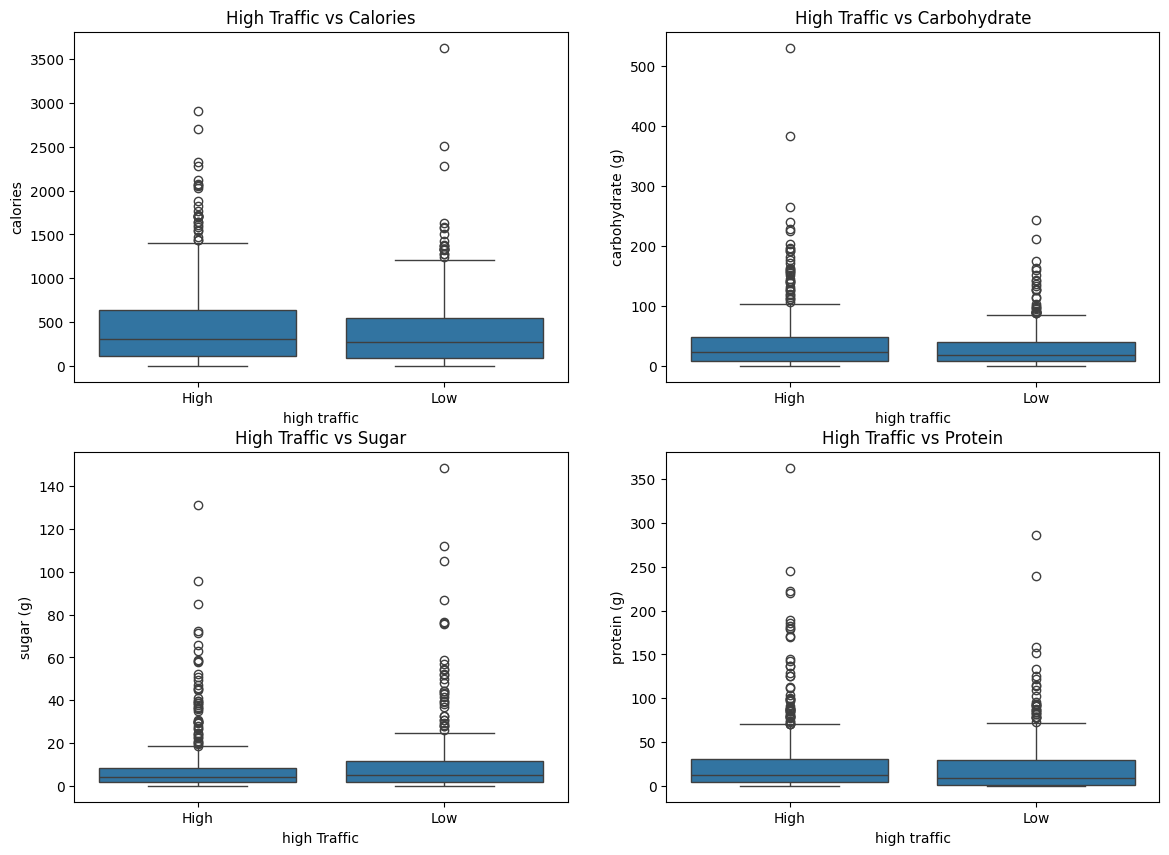

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# 'high_traffic' , 'calories'
sns.boxplot(x='high_traffic', y='calories', data=df_final_data, ax=axs[0, 0])
axs[0, 0].set_title('High Traffic vs Calories')
axs[0, 0].set_xlabel('high traffic')
axs[0, 0].set_ylabel('calories')

# 'high_traffic' , 'carbohydrate'
sns.boxplot(x='high_traffic', y='carbohydrate', data=df_final_data, ax=axs[0, 1])
axs[0, 1].set_title('High Traffic vs Carbohydrate')
axs[0, 1].set_xlabel('high traffic')
axs[0, 1].set_ylabel('carbohydrate (g)')

# 'high_traffic' , 'sugar'
sns.boxplot(x='high_traffic', y='sugar', data=df_final_data, ax=axs[1, 0])
axs[1, 0].set_title('High Traffic vs Sugar')
axs[1, 0].set_xlabel('high Traffic')
axs[1, 0].set_ylabel('sugar (g)')

# 'high_traffic' , 'protein'
sns.boxplot(x='high_traffic', y='protein', data=df_final_data, ax=axs[1, 1])
axs[1, 1].set_title('High Traffic vs Protein')
axs[1, 1].set_xlabel('high traffic')
axs[1, 1].set_ylabel('protein (g)')

plt.show()

Pentru a percepe mai bine relația dintre categorii și traficul ridicat, se va crea o histogramă.

Pe baza analizei histogramei, categoria 'Potato' are un impact puternic în ceea ce privește traficul ridicat (având o frecvență de aproximatix 80), căreia i se alătură categoria 'Vegetable', care este foarte apropiată de cea dintâi în ceea ce privește numărul de apariții de trafic ridicat.

De asemenea, următoarea în ordinea traficului ridicat ar fi categoria 'Chicken', dar aceasta este și prima care poate influența apariția unui trafic scăzut. Aproape de categoria 'Chicken' în ceea ce privește numărul de apariții de trafic ridicat este categoria 'Pork'. Iar în ceea ce privește a doua categorie care poate influența negativ traficul este 'Beverages'. Restul categoriilor au mai puțin de 60 de apariții pentru o valoare de trafic ridicat.

Astfel, categoriile care au potențialul de a genera un trafic ridicat sunt, în această ordine, 'Potato', 'Vegetable', 'Chicken' și 'Pork'.

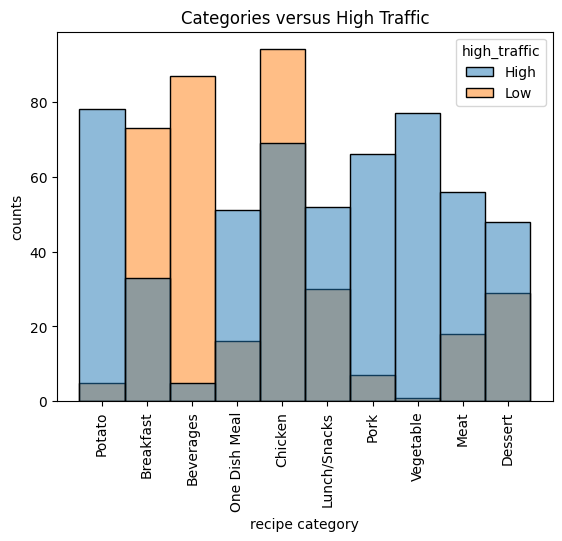

In [ ]:
sns.histplot(x='category', hue='high_traffic',bins=30 ,data=df_final_data)
plt.title('Categories versus High Traffic')
plt.xlabel('recipe category')
plt.ylabel('counts')
plt.xticks(rotation=90, ha='center')
plt.show()

Pentru o mai bună vizualizare a ordinii în care categoriile pot influența traficul ridicat, valorile normalizate facilitează compararea proporțiilor relative ale rețetelor cu trafic ridicat între categorii.

Din graficul cu bare orizontale care arată proporțiile valorilor coloanei 'High traffic' din fiecare categorie, care a fost sortat pentru o mai bună vizualizare, se poate observa că numai 3 categorii au o valoare mai mare de 0.8, ceea ce înseamnă că sigur 80% dintre rețetele din categoriile respective ('Vegetable', 'Potato', 'Pork') sunt etichetate ca fiind 'High'. În plus, categoriile 'One Dish Meal' și 'Meat' au o valoare mai apropiată de 0.8, ceea ce înseamnă că aceste categorii pot influența, de asemenea, traficul ridicat.

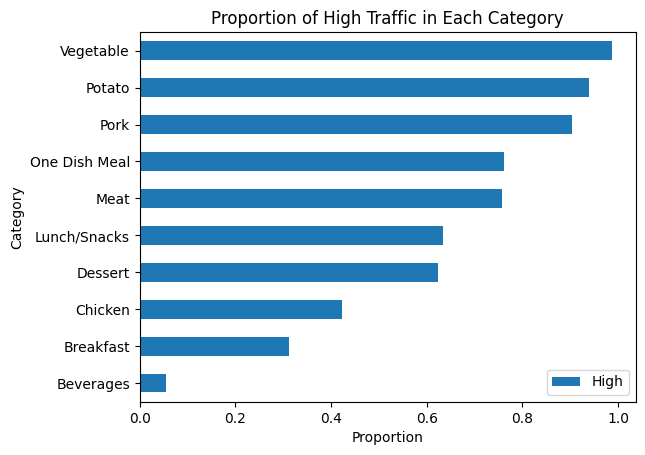

In [ ]:
high_traffic_procent_query = """
SELECT category,
       SUM(CASE WHEN high_traffic = 'High' THEN 1 ELSE 0 END) / COUNT(*) AS High
FROM recipe_site_traffic_final
GROUP BY category
ORDER BY High
"""

high_traffic_procent_result = spark.sql(high_traffic_procent_query)

df_high_traffic_procent = high_traffic_procent_result.toPandas()

df_high_traffic_procent.plot(kind='barh', x='category', y='High')
plt.title('Proportion of High Traffic in Each Category')
plt.xlabel('Proportion')
plt.ylabel('Category')
plt.show()

Pentru a vizualiza relația dintre high_traffic și porții, a fost creat un box plot.

După analizarea acestuia, s-a observat că valoarea medie atât pentru "High", cât și pentru "Low" este aceeași, iar dimensiunea cutiei este aceeași. Aceste observații conduc la concluzia că valorile din coloana 'Servings' nu reprezintă un factor distinctiv pentru a prezice dacă o rețetă va fi asociată cu un trafic ridicat sau nu.

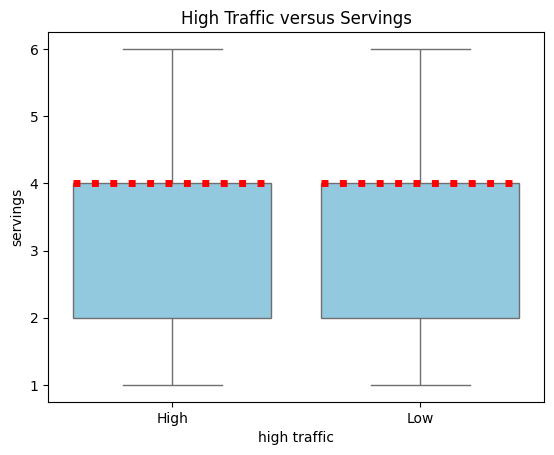

In [ ]:
sns.boxplot(x='high_traffic', y='servings', data=df_final_data,color='skyblue',medianprops={'color': 'red', 'ls': ':', 'lw': 5})

plt.title('High Traffic versus Servings')
plt.xlabel('high traffic')
plt.ylabel('servings')

plt.show()

Pentru fiecare categorie se dorește aflarea distribuției valorii medii a caloriilor, doar dacă numărul de porții are valoarea cel puțin 4.

S-au realizat două grafice pentru a compara care este mai ușor de interpretat și care oferă o vizibilitate mai bună a valorilor pentru a fi studiate. Dintre cele două grafice: „point plot” și „bar plot”, pentru a putea studia ceea ce s-a propus consider că cel de-al doilea oferă o mai bună vizibilitate, pentru că este mai ușor de urmărit valoarea din dreptul unei bare, decât de urmărit punctele.

Din aceste grafice se observă că valoarea cea mai mare privind media de calorii este prezentă la categoria 'Pork', fiind urmată de 'Chicken', 'Meat' și 'One Dish Meal', în această ordine. Aceste categorii având valoarea medie a caloriilor peste 500 se detașază de restul categoriilor care au valori sub aproximativ valoarea de 450.

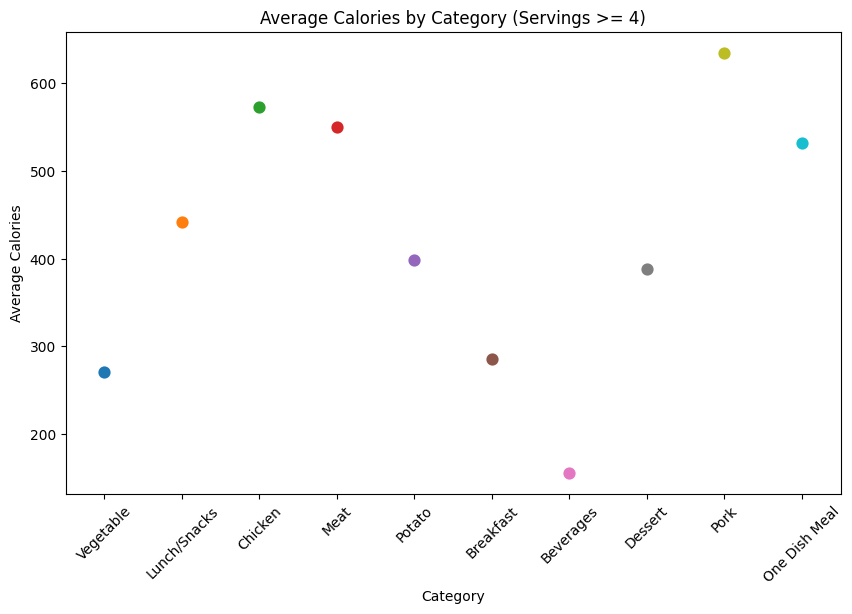

In [ ]:
category_avg_nutritional = spark.sql("SELECT category, avg(calories) avg_cal, avg(carbohydrate) avg_carb, avg(sugar) avg_sugar, avg(protein) avg_protein FROM recipe_site_traffic_final where servings>=4 group by category")
#category_avg_nutritional.show()
df_category_avg_nutritional= category_avg_nutritional.toPandas()

plt.figure(figsize=(10, 6))
sns.pointplot(x='category', y='avg_cal', data=df_category_avg_nutritional,hue='category')
plt.title('Average Calories by Category (Servings >= 4)')
plt.xlabel('Category')
plt.ylabel('Average Calories')
plt.xticks(rotation=45)
plt.show()

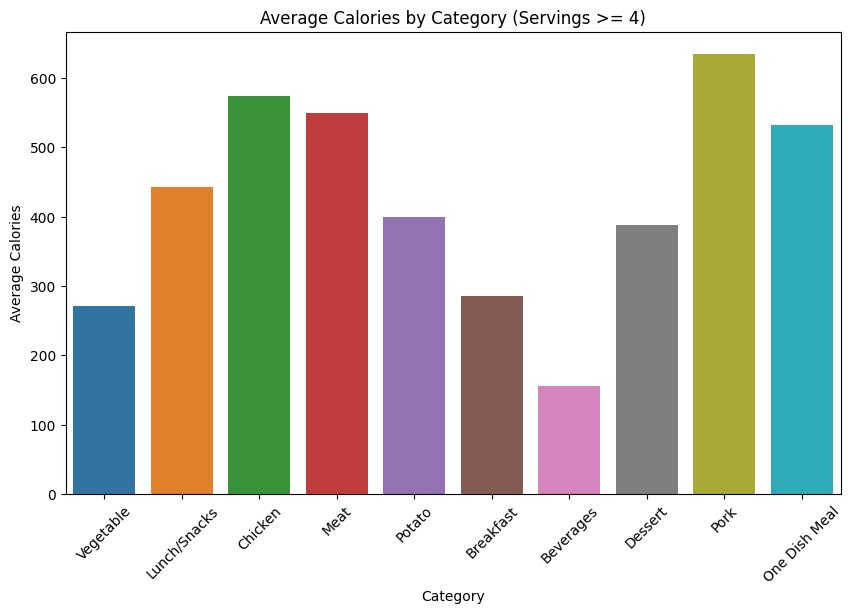

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='avg_cal', data=df_category_avg_nutritional,hue='category')
plt.title('Average Calories by Category (Servings >= 4)')
plt.xlabel('Category')
plt.ylabel('Average Calories')
plt.xticks(rotation=45)
plt.show()

Pentru a putea studia comparativ în funcție de categorii valorile medii obținute pentru fiecare dintre elementele nutriționale, s-a recurs la crearea unui grafic cu bare grupate.

În urma analizei graficului, s-a observat că în ceea ce privește valoarea medie a caloriilor, categoria 'Pork' are cea mai mare valoare, fiind aproximativ egală cu 640, iar cea mai mică valoare este întâlnită la categoria 'Beverages'. În cazul valorii medii a carbohidraților, cea mai mare valoare este a categoriei 'One Dish Meal' de a cărei valoare se apropie și categoria 'Dessert'; cea mai mică valoare fiind a categoriei 'Pork'. Categoria care are valoarea cea mai mare pentru valoarea medie a zahărului este 'Dessert' care se distinge vizibil de restul categoriilor. În ceea ce privește valoarea medie a proteinelor, categoria 'Pork' are cea mai mare valoare, cea mai mică fiind regăsită în categoria 'Beverages'.

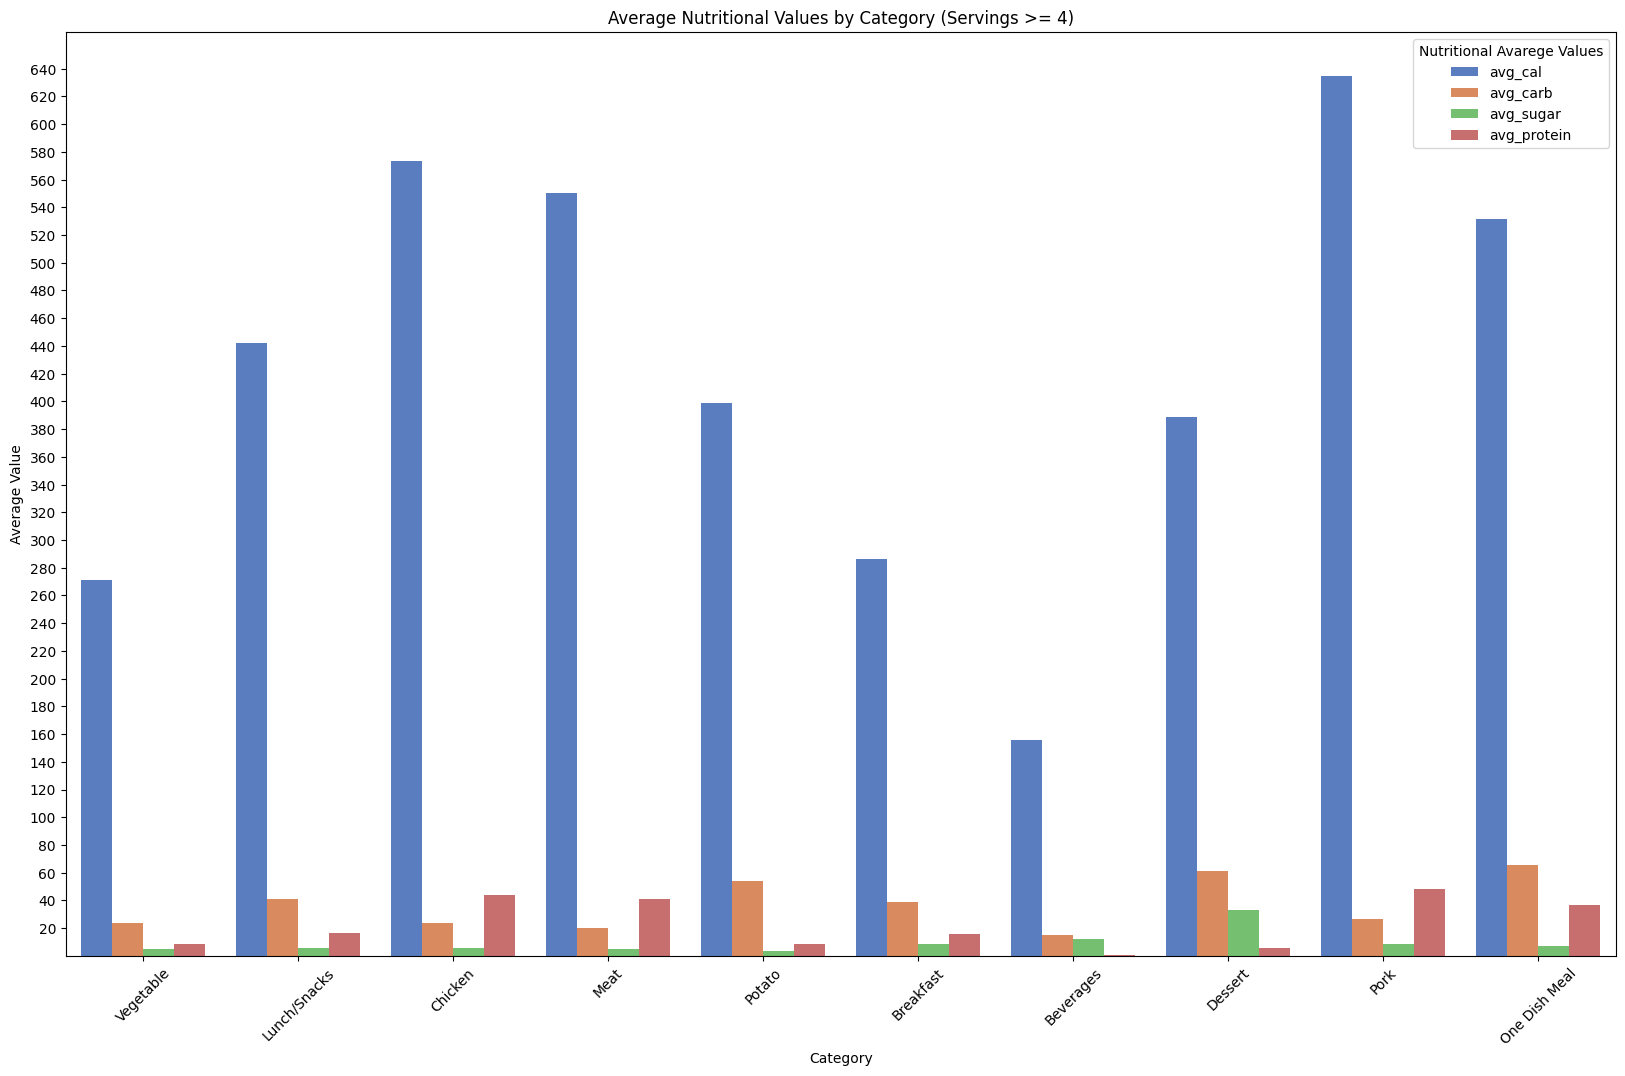

In [ ]:
# coloana 'variable_name' va conține numele originale ale coloanelor
# coloana 'nutritional_value' conține valorile originale
new_data = pd.melt(df_category_avg_nutritional, id_vars='category', var_name='variable_name', value_name='nutritional_value')

# Crearea grouped bar plot
plt.figure(figsize=(20, 12))
sns.barplot(x='category', y='nutritional_value', hue='variable_name', data=new_data, palette='muted')
plt.title('Average Nutritional Values by Category (Servings >= 4)')
plt.xlabel('Category')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.yticks(range(20, int(new_data['nutritional_value'].max()) + 20, 20))
plt.legend(title='Nutritional Avarege Values')
plt.show()

# 3. Aplicarea a două modele de ML (sunt incluse și cerintele 4 și 5)

## Dezvoltarea modelului

Problema ce se dorește a fi rezolvată este prezicerea dacă traficul este „Low” sau „High”, ceea ce se rezumă la o problemă de clasificare pentru care s-a ales folosirea a două modele: regresia logistică și arborele de decizie pentru clasificare.

Primul model - regresia logistică - a fost ales, deoarece este cel mai bun pentru problemele de clasificare, fiind eficient atunci când relațiile dintre caracteristici și varaibila țintă sunt aproximativ liniare. Mai mult, acest model a fost ales și pentru că este ușor de interpretat.

Al doilea model - arborele de decizie pentru clasificare - a fost ales, pentru că poate modela relații complexe de date, este ușor de interpretat și oferă importanța caracteristicilor.

## Preprocesarea datelor

Având în vedere cerința de a prezice felul în care este traficul: „Low” sau „High”, variabila țintă este 'high_traffic', iar dintre valorile independente fac parte: 'calories', 'carbohydrate', 'sugar', 'protein', 'category' și 'servings'.

În acest pas de preprocesare se vor face următoarele modificări ale datelor:


*   Corecția înclinației datelor (s-a observat că acestea sunt right-skewed)
*   Convertirea șirurilor de caractere în valori numerice în cazul valorilor din coloana 'category'
*   Transformarea valorilor din coloana 'high_traffic' (High/Low) în valori numerice astfel: 1 corespunde pentru valorile „High”, respectiv 0 pentru valorile „Low”
*   Eliminarea coloanei 'recipe'







In [ ]:
df.show()

+------+--------+------------+-----+-------+-------------+--------+------------+
|recipe|calories|carbohydrate|sugar|protein|     category|servings|high_traffic|
+------+--------+------------+-----+-------+-------------+--------+------------+
|     2|   35.48|       38.56| 0.66|   0.92|       Potato|       4|        High|
|     3|  914.28|       42.68| 3.09|   2.88|    Breakfast|       1|         Low|
|     4|   97.03|       30.56|38.63|   0.02|    Beverages|       4|        High|
|     5|   27.05|        1.85|  0.8|   0.53|    Beverages|       4|         Low|
|     6|  691.15|        3.46| 1.65|  53.93|One Dish Meal|       2|        High|
|     7|  183.94|       47.95| 9.75|  46.71|      Chicken|       4|         Low|
|     8|  299.14|        3.17|  0.4|   32.4| Lunch/Snacks|       4|         Low|
|     9|  538.52|        3.78| 3.37|   3.79|         Pork|       6|        High|
|    10|  248.28|       48.54| 3.99| 113.85|      Chicken|       2|         Low|
|    11|  170.12|       17.6

## 4+5. Pipeline + UDF

Pentru acest pas s-a creat un Pipeline care conține următorii pași ai preprocesării datelor:
* convertirea șirurilor de caractere în valori numerice în cazul valorilor din coloana 'category' prin folosirea StringIndexer.
* transformarea datelor din coloana High_Traffic în 0 și 1, prin crearea unui transformator custom (HighTrafficTransformer) care utilizează o funcție definită de utilizator (UDF) pentru a face conversia datelor.
* eliminarea coloanei 'recipe' a necesitat crearea unui transformator custom (ColumnDropTransformer) care realizează acțiunea de drop
* eliminarea coloanei inițiale 'category' se va face prin utilizarea transformatorului definit mai sus
* redenumirea coloanei 'categoryIndexer' în 'category' pentru a păstra un nume semnificativ, prin crearea unui transformator custom (RenameColumnTransformer)

In [ ]:
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import udf
from pyspark.ml import Pipeline, Transformer
from pyspark.ml.feature import StringIndexer
from pyspark.sql.types import IntegerType
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable


category_indexer = StringIndexer(inputCol="category", outputCol="categoryIndex")

def high_traffic_to_numeric_val(value):
    return 0 if value == "Low" else 1

high_traffic_udf = udf(high_traffic_to_numeric_val, IntegerType())

class HighTrafficTransformer(Transformer, DefaultParamsReadable, DefaultParamsWritable):
    def _transform(self, df):
        return df.withColumn('high_traffic', high_traffic_udf(df['high_traffic']))


class ColumnDropTransformer(Transformer, DefaultParamsReadable, DefaultParamsWritable): #pentru serializare și deserializare
    def __init__(self, columns=None):
        super(ColumnDropTransformer, self).__init__()
        self.columns = columns

    def _transform(self, df):
        return df.drop(*self.columns)

class RenameColumnTransformer(Transformer, DefaultParamsReadable, DefaultParamsWritable):
    def __init__(self, original_col=None, new_col=None):
        super(RenameColumnTransformer, self).__init__()
        self.original_col = original_col
        self.new_col = new_col

    def _transform(self, df):
        return df.withColumnRenamed(self.original_col, self.new_col)

high_traffic_transformer = HighTrafficTransformer()
drop_column_recipe_transformer = ColumnDropTransformer(columns=['recipe'])
drop_column_categ_transformer = ColumnDropTransformer(columns=['category'])
rename_column_categIndex_transformer = RenameColumnTransformer(original_col='categoryIndex', new_col='category')

pipeline = Pipeline(stages=[
    category_indexer,
    high_traffic_transformer,
    drop_column_recipe_transformer,
    drop_column_categ_transformer,
    rename_column_categIndex_transformer
])
df = pipeline.fit(df).transform(df)

df.show()

+--------+------------+-----+-------+--------+------------+--------+
|calories|carbohydrate|sugar|protein|servings|high_traffic|category|
+--------+------------+-----+-------+--------+------------+--------+
|   35.48|       38.56| 0.66|   0.92|       4|           1|     3.0|
|  914.28|       42.68| 3.09|   2.88|       1|           0|     1.0|
|   97.03|       30.56|38.63|   0.02|       4|           1|     2.0|
|   27.05|        1.85|  0.8|   0.53|       4|           0|     2.0|
|  691.15|        3.46| 1.65|  53.93|       2|           1|     9.0|
|  183.94|       47.95| 9.75|  46.71|       4|           0|     0.0|
|  299.14|        3.17|  0.4|   32.4|       4|           0|     4.0|
|  538.52|        3.78| 3.37|   3.79|       6|           1|     8.0|
|  248.28|       48.54| 3.99| 113.85|       2|           0|     0.0|
|  170.12|       17.63|  4.1|   0.91|       1|           0|     2.0|
|   155.8|        8.27| 9.78|  11.55|       6|           0|     1.0|
|  274.63|       23.49| 1.56|   2.

## Continuare Preprocesare

Pentru a corecta înclinația datelor din coloanele nutriționale: 'calories', 'carbohydrate', 'sugar', 'protein' care prezintă o distribuție de tipul right-skewed s-a ales transformarea logaritmică care omogenizează datele și reduce asimetria distribuției datelor.

La această transformare s-a adăugat StandardScaler pentru aceleași coloane prin care se normalizează vectorul de caracteristici 'features' pentru a avea medie zero și deviație standard unitară, rezultând o coloană 'scaled_features'.

Pentru a putea extrage valorile individuale, vectorul scalat este convertit într-un array.

În final datele inițiale din dataFrame-ul original sunt înlocuite de cele scalate, care vor fi redenumite, eliminându-se coloana temporară 'temp_id' pe baza căreia s-a realizat operația de Join.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import log1p, col,monotonically_increasing_id
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.functions import vector_to_array
df = df.withColumn("temp_id", monotonically_increasing_id())

# Aplicarea transformării log pentru a reduce skewness
df_log = df.withColumn("log_calories", log1p(col("calories")))\
           .withColumn("log_carbohydrate", log1p(col("carbohydrate")))\
           .withColumn("log_sugar", log1p(col("sugar")))\
           .withColumn("log_protein", log1p(col("protein")))

# Combină features transformate într-o singură coloană care este sub formă de vector
assembler = VectorAssembler(inputCols=["log_calories", "log_carbohydrate", "log_sugar", "log_protein"], outputCol="features")
df_vector = assembler.transform(df_log)

# Scalarea features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features",withMean=True,withStd=True)
scaler_model = scaler.fit(df_vector)
scaled_data = scaler_model.transform(df_vector)

# Convertire vectorului de features scalat în array
scaled_data = scaled_data.withColumn("scaled_features_array", vector_to_array(col("scaled_features")))

# Convertirea features scalate înapoi în coloane separate
scaled_df = scaled_data.select(
    col("temp_id"),
    col("scaled_features_array")[0].alias("scaled_calories"),
    col("scaled_features_array")[1].alias("scaled_carbohydrate"),
    col("scaled_features_array")[2].alias("scaled_sugar"),
    col("scaled_features_array")[3].alias("scaled_protein")
)

# Join features scalate înapoi cu DataFrame-ul original
df = df.join(scaled_df, on="temp_id", how="inner") \
    .drop("temp_id", "calories", "carbohydrate", "sugar", "protein") \
    .withColumnRenamed("scaled_calories", "calories") \
    .withColumnRenamed("scaled_carbohydrate", "carbohydrate") \
    .withColumnRenamed("scaled_sugar", "sugar") \
    .withColumnRenamed("scaled_protein", "protein")

df.show()

+--------+------------+--------+--------------------+--------------------+--------------------+--------------------+
|servings|high_traffic|category|            calories|        carbohydrate|               sugar|             protein|
+--------+------------+--------+--------------------+--------------------+--------------------+--------------------+
|       4|           1|     3.0|  -1.430132362614368|  0.5859450651540941| -1.2594435995618145| -1.3419972688296533|
|       1|           0|     1.0|   1.034729250117547|   0.672368888921708| -0.3475814335813503| -0.8105560944783694|
|       4|           1|     2.0| -0.6740223164031365|  0.3888600454983377|  1.9489850967355566| -1.8198135640041773|
|       4|           0|     2.0| -1.6311291703686899| -1.7087324874100316| -1.1775645061354407| -1.5135196277982141|
|       2|           1|     9.0|  0.8209955066981273| -1.3180747777727637| -0.7864444674226196|  1.1914601209859714|
|       4|           0|     0.0|-0.18849648819187254|  0.7717357

Pentru a studia noua distribuție a datelor DataFrame-ul este transformat într-unul de tip Pandas pentru a putea face o reprezentare grafică.

In [ ]:
df.createOrReplaceTempView("recipe_site_traffic_no_skew")
no_skew_data = spark.sql("SELECT * FROM recipe_site_traffic_no_skew")
no_skew_data.show()
df_no_skew_data = no_skew_data.toPandas()

+--------+------------+--------+--------------------+--------------------+--------------------+--------------------+
|servings|high_traffic|category|            calories|        carbohydrate|               sugar|             protein|
+--------+------------+--------+--------------------+--------------------+--------------------+--------------------+
|       4|           1|     3.0|  -1.430132362614368|  0.5859450651540941| -1.2594435995618145| -1.3419972688296533|
|       1|           0|     1.0|   1.034729250117547|   0.672368888921708| -0.3475814335813503| -0.8105560944783694|
|       4|           1|     2.0| -0.6740223164031365|  0.3888600454983377|  1.9489850967355566| -1.8198135640041773|
|       4|           0|     2.0| -1.6311291703686899| -1.7087324874100316| -1.1775645061354407| -1.5135196277982141|
|       2|           1|     9.0|  0.8209955066981273| -1.3180747777727637| -0.7864444674226196|  1.1914601209859714|
|       4|           0|     0.0|-0.18849648819187254|  0.7717357

Crearea de histograme pentru a vedea noua distribuție a datelor din coloanele modificate ('calories','carbohydrate','sugar','protein'). Se poate remarca faptul că distribuția datelor s-a modificat considerabil, fiind mult mai apropiată de o distribuție normală, ceea ce permite antrenarea, testarea și evaluarea setului de date.

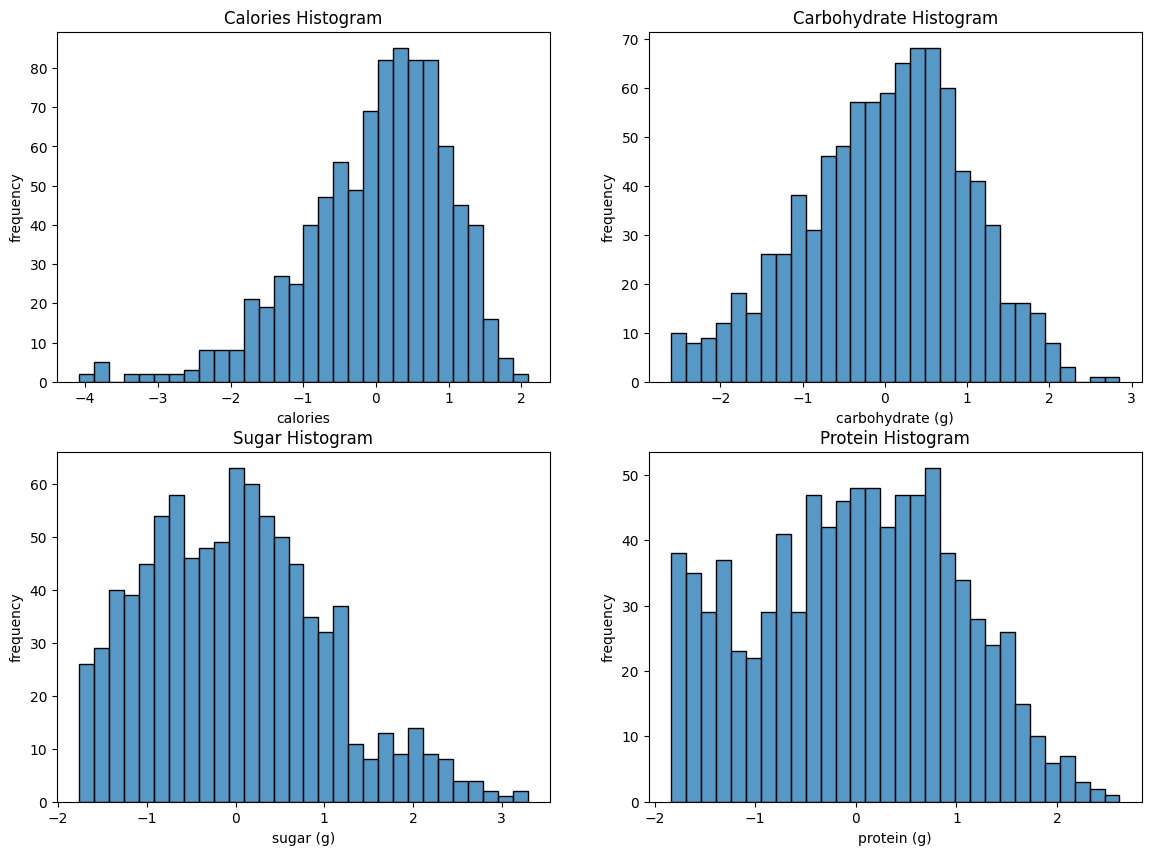

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Calories Histogram
sns.histplot(data=df_no_skew_data, x='calories', bins=30, ax=axs[0, 0])
axs[0, 0].set_title('Calories Histogram')
axs[0, 0].set_xlabel('calories')
axs[0, 0].set_ylabel('frequency')

# Carbohydrate Histogram
sns.histplot(data=df_no_skew_data, x='carbohydrate', bins=30, ax=axs[0, 1])
axs[0, 1].set_title('Carbohydrate Histogram')
axs[0, 1].set_xlabel('carbohydrate (g)')
axs[0, 1].set_ylabel('frequency')

# Sugar Histogram
sns.histplot(data=df_no_skew_data, x='sugar', bins=30, ax=axs[1, 0])
axs[1, 0].set_title('Sugar Histogram')
axs[1, 0].set_xlabel('sugar (g)')
axs[1, 0].set_ylabel('frequency')

# Protein Histogram
sns.histplot(data=df_no_skew_data, x='protein', bins=30, ax=axs[1, 1])
axs[1, 1].set_title('Protein Histogram')
axs[1, 1].set_xlabel('protein (g)')
axs[1, 1].set_ylabel('frequency')

plt.show()

In [ ]:
df.show()

+--------+------------+--------+--------------------+--------------------+--------------------+--------------------+
|servings|high_traffic|category|            calories|        carbohydrate|               sugar|             protein|
+--------+------------+--------+--------------------+--------------------+--------------------+--------------------+
|       4|           1|     3.0|  -1.430132362614368|  0.5859450651540941| -1.2594435995618145| -1.3419972688296533|
|       1|           0|     1.0|   1.034729250117547|   0.672368888921708| -0.3475814335813503| -0.8105560944783694|
|       4|           1|     2.0| -0.6740223164031365|  0.3888600454983377|  1.9489850967355566| -1.8198135640041773|
|       4|           0|     2.0| -1.6311291703686899| -1.7087324874100316| -1.1775645061354407| -1.5135196277982141|
|       2|           1|     9.0|  0.8209955066981273| -1.3180747777727637| -0.7864444674226196|  1.1914601209859714|
|       4|           0|     0.0|-0.18849648819187254|  0.7717357

În cele ce urmează se pregătesc datele pentru a fi antrenate. Se construiește un VectorAssembler care include toate coloanele mai puțin pe cea de interes - 'high_traffic' - care va fi redenumită 'label'.

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

assembler_v = VectorAssembler(
    inputCols=['calories', 'carbohydrate', 'sugar', 'protein', 'category', 'servings'],
    outputCol='features'
)

# Aducerea features într-un singur vector
assembled_df = assembler_v.transform(df)
assembled_df.show()

# Select the required columns for the model
data = assembled_df.select('features', 'high_traffic')
data = data.withColumnRenamed("high_traffic", "label")
data.show()

+--------+------------+--------+--------------------+--------------------+--------------------+--------------------+--------------------+
|servings|high_traffic|category|            calories|        carbohydrate|               sugar|             protein|            features|
+--------+------------+--------+--------------------+--------------------+--------------------+--------------------+--------------------+
|       4|           1|     3.0|  -1.430132362614368|  0.5859450651540941| -1.2594435995618145| -1.3419972688296533|[-1.4301323626143...|
|       1|           0|     1.0|   1.034729250117547|   0.672368888921708| -0.3475814335813503| -0.8105560944783694|[1.03472925011754...|
|       4|           1|     2.0| -0.6740223164031365|  0.3888600454983377|  1.9489850967355566| -1.8198135640041773|[-0.6740223164031...|
|       4|           0|     2.0| -1.6311291703686899| -1.7087324874100316| -1.1775645061354407| -1.5135196277982141|[-1.6311291703686...|
|       2|           1|     9.0|  

În cele ce urmează setul de date este împărțit în date de antrenare și date de testare respectând proporția: 70% dintre date sunt pentru antrenare, iar restul de 30% sunt pentru testare. Argumentul 'seed' are rolul de a asigura reproductibilitatea împărțirii aleatorii a datelor (răspunsul oferit este același la fiecare rulare) De asemenea, s-a ales separarea caracteristicilor și etichetelor datelor de antrenare și testare pentru a oferi o vizualizare mai bună.

In [ ]:
train_data, test_data = data.randomSplit([0.7, 0.3], seed=2500)
X_train_ = train_data.select('features')
y_train_ = train_data.select('label')

# Separarea features și labels pentru date de testare
X_test_ = test_data.select('features')
y_test_ = test_data.select('label')

# Exemple pentru training și testing features and labels
print("Training Features:")
X_train_.show(5)

print("Training Labels:")
y_train_.show(5)

print("Testing Features:")
X_test_.show(5)

print("Testing Labels:")
y_test_.show(5)

Training Features:
+--------------------+
|            features|
+--------------------+
|[-4.0810709904771...|
|[-3.8510243668168...|
|[-3.7488863255170...|
|[-3.7316968467243...|
|[-3.4622836167570...|
+--------------------+
only showing top 5 rows

Training Labels:
+-----+
|label|
+-----+
|    1|
|    1|
|    1|
|    0|
|    1|
+-----+
only showing top 5 rows

Testing Features:
+--------------------+
|            features|
+--------------------+
|[-3.9806121802580...|
|[-3.8265846367906...|
|[-3.8029016490870...|
|[-3.1247530351120...|
|[-2.9173004859247...|
+--------------------+
only showing top 5 rows

Testing Labels:
+-----+
|label|
+-----+
|    0|
|    1|
|    0|
|    0|
|    0|
+-----+
only showing top 5 rows



## Logistic Regression

Aplicați o metodă de ML prin care să reușiți să obțineți rezultate cât mai bune în ceea ce privește problema de clasificare. Folosiți diverși parametrii și verificați acuratețea și precizia metodei alese.

Primul model utilizat este LogisticRegression și a fost ales, deoarece este cel mai bun pentru problemele de clasificare, fiind eficient atunci când relațiile dintre caracteristici și varaibila țintă sunt aproximativ liniare. Mai mult, acest model a fost ales și pentru că este ușor de interpretat.

Pentru a se obține cel mai bun model de regresie logistică s-a folosit Grid Search și Cross Validation care au rolul de a ajuta la găsirea celor mai buni parametrii pentru modelul dorit (hyperparameter tuning).

Prin utilizarea Cross Validation se va testa fiecare combinație de parametrii din Grid și ulterior se va putea alege cel mai bun model care are cea mai bună combinație a parametrilor.

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

lr = LogisticRegression(featuresCol='features', labelCol='label')

# Hiperparametrii
paramGrid = (ParamGridBuilder()
             # parametrul de regularizare folosit pentru prevenirea overfitting-ului (trebuie găsită valoarea optimă pentru a minimiză eroarea din timpul antrenării și testării)
             .addGrid(lr.regParam, [0.00001, 0.0001, 0.001, 0.01])
             # parametrul ElasticNet ia valori în intervalul [0,1] și controlează echilibrul dintre regularizarea Lasso (L1) și Ridge (L2)
             # valoarea 0 corespunde lui L2, iar valoarea 1 lui L1, iar valorile intermediare sunt un amestec al celor două regularizări
             .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
             # numărul maxim de iterații care sunt făcute penrtu a ajunge la soluția optimă
             .addGrid(lr.maxIter,[10,50,100])
             .build())
crossval = CrossValidator(
                          # modelul care se dorește a fi evaluat și testat prin Cross Validation
                          estimator=lr,
                          # parametrii pentru care dorim să găsim combinația optimă
                          estimatorParamMaps=paramGrid,
                          # evaluatorul este BinaryClassificationEvaluator, deoarece este o problemă de clasificare binară, iar metrica utilizată este areaUnderROC
                          # (cu cât valoarea de sub curbă este mai mare, cu atât modelul este considerat mai bun)
                          evaluator=BinaryClassificationEvaluator( labelCol='label', metricName='areaUnderROC'),
                          # numărul de fold-uri în care va fi împărțit setul de date pentru a se realiza Cross Validation
                          numFolds=5)
# Antrenarea modelului
cvModel = crossval.fit(train_data)

# Obținerea celui mai bun model
bestModel = cvModel.bestModel

Evaluarea modelului de antrenare

In [ ]:
trainDataSummary = bestModel.summary # se pot obține informații despre performanța modelului și despre iterațiile sale
# pentru fiecare iterație se va obține funcția obiectiv care măsoară performanța modelului
objectiveHistory = trainDataSummary.objectiveHistory
print("objectiveHistory:")
for objective in objectiveHistory:
    print(objective)

# Obține valoarea ROC ca dataframe și valoarea areaUnderROC.
trainDataSummary.roc.show() # ROC este utilizat pentru a face graficul dintre rata 'true positive' (TPR) și rata 'false positive' (FPR)
print("areaUnderROC: " + str(trainDataSummary.areaUnderROC)) # cu cât AUC este mai mare, cu atât modelul este mai bun

# Setarea pragului modelului pentru a maximiza măsura F
fMeasure = trainDataSummary.fMeasureByThreshold # măsură a preciziei modelului
# obținerea valorii maxime a lui F și a pragului acelei valori, fiind urmat de setarea pragului modelului la pragul optim calculat
maxFMeasure = fMeasure.groupBy().max('F-Measure').select('max(F-Measure)').head()
bestThreshold = fMeasure.where(fMeasure['F-Measure'] == maxFMeasure['max(F-Measure)']) \
    .select('threshold').head()['threshold']
lr.setThreshold(bestThreshold)


objectiveHistory:
0.6680465321852159
0.5878205493731461
0.5818221711121099
0.5816507431788164
0.581648347526106
0.5816481765275455
0.581648172088293
0.581648171195415
0.5816481711936133
+--------------------+--------------------+
|                 FPR|                 TPR|
+--------------------+--------------------+
|                 0.0|                 0.0|
|                 0.0|0.002624671916010...|
|                 0.0|0.005249343832020997|
|                 0.0|0.007874015748031496|
|                 0.0|0.010498687664041995|
|                 0.0|0.013123359580052493|
|                 0.0|0.015748031496062992|
|                 0.0| 0.01837270341207349|
|                 0.0| 0.02099737532808399|
|                 0.0|0.023622047244094488|
|                 0.0|0.026246719160104987|
|0.004132231404958678|0.026246719160104987|
|0.004132231404958678|0.028871391076115485|
|0.004132231404958678|0.031496062992125984|
|0.004132231404958678| 0.03412073490813648|
|0.004132231404958678|

LogisticRegression_ed4e6f3d1dfd

Având în vederea valoarea obținută pentru AUC este una acceptabilă, iar pentru o mai bună vizualizare se va trasa graficul pentru a reprezenta curba ROC.

Reprezentarea curbei ROC

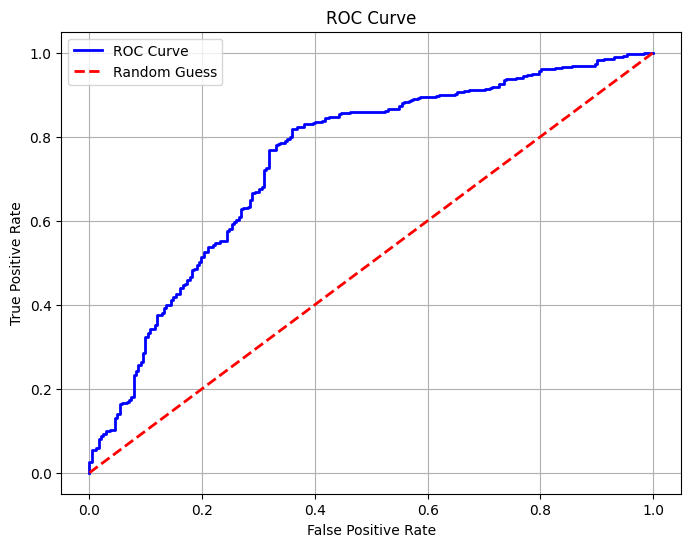

In [ ]:
fpr_lr_val = trainDataSummary.roc.select('FPR').collect()
tpr_lr_val = trainDataSummary.roc.select('TPR').collect()

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_val, tpr_lr_val, color='blue', lw=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

În cele ce urmează se vor verifica valorile pentru FP,TP, precizie, recall, F-measure în funcție de label, dar și per total.

In [ ]:
print("False positive rate:")
for lab, rate in enumerate(trainDataSummary.falsePositiveRateByLabel):
    print("label %d: %s" % (lab, rate))

print("True positive rate:")
for lab, rate in enumerate(trainDataSummary.truePositiveRateByLabel):
    print("label %d: %s" % (lab, rate))

print("Precision:")
for lab, precision in enumerate(trainDataSummary.precisionByLabel):
    print("label %d: %s" % (lab, precision))

print("Recall:")
for lab, recall in enumerate(trainDataSummary.recallByLabel):
    print("label %d: %s" % (lab, recall))

print("F-measure:")
for lab, f in enumerate(trainDataSummary.fMeasureByLabel()):
    print("label %d: %s" % (lab, f))

accuracy = trainDataSummary.accuracy
falsePositiveRate = trainDataSummary.weightedFalsePositiveRate
truePositiveRate = trainDataSummary.weightedTruePositiveRate
fMeasure = trainDataSummary.weightedFMeasure()
precision = trainDataSummary.weightedPrecision
recall = trainDataSummary.weightedRecall
print("Accuracy: %s\nFPR: %s\nTPR: %s\nF-measure: %s\nPrecision: %s\nRecall: %s"
      % (accuracy, falsePositiveRate, truePositiveRate, fMeasure, precision, recall))

False positive rate:
label 0: 0.19160104986876642
label 1: 0.359504132231405
True positive rate:
label 0: 0.640495867768595
label 1: 0.8083989501312336
Precision:
label 0: 0.6798245614035088
label 1: 0.779746835443038
Recall:
label 0: 0.640495867768595
label 1: 0.8083989501312336
F-measure:
label 0: 0.6595744680851063
label 1: 0.7938144329896907
Accuracy: 0.7431781701444623
FPR: 0.2942833522446337
TPR: 0.7431781701444623
F-measure: 0.7416698559320511
Precision: 0.7409327257840235
Recall: 0.7431781701444623


Realizarea de predicții pe setul de testare și evaluarea acestuia

In [ ]:
# Realizarea predicțiilor pe setul de testare
predictions = bestModel.transform(test_data)

# Evaluarea performanței modelului
evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
roc_auc = evaluator.evaluate(predictions)

# calcularea preciziei = TP/ (TP + FP)
# TP = numărul de preziceri adevărate care în clasa reală erau adevărate
true_positives = predictions.filter((predictions.label == 1) & (predictions.prediction == 1)).count()
# TP + FP = numărul total de predicții adevărate
predicted_positives = predictions.filter(predictions.prediction == 1).count()
precision = true_positives / predicted_positives if predicted_positives != 0 else 0

# calcularea acurateții = (TP + TN)/(TP+TN+FP+FN)
# (TP + TN + FP + FN) se poate calcula prin parcurgerea tuturor predicțiilor și numărarea valorilor de 1
total_predictions = predictions.count()
# (TP + TN) sunt acele rezultate pentru care răspunsul dat de predicție este același cu cel real.
correct_predictions = predictions.filter(col('label') == col('prediction')).count()

accuracy = correct_predictions / total_predictions


# vizualizarea parametrilor optimi ai celui mai bun model
print("Optim parameters: ", bestModel.extractParamMap())

# afișarea ariei de sub curbă
print("Area Under ROC Curve: ", roc_auc)

print("Precision: ", precision)

print("Accuracy: ", accuracy)

# coeficienții modelului ajută la descoperirea caracteristicii cu influență mai mare asupra predicției
# (cu cât coeficientul este mai mare cu atât influențează mai mult)
coefs = bestModel.coefficients
print("Coefficients: ", coefs)
print("Intercept: " + str(bestModel.intercept))

Optim parameters:  {Param(parent='LogisticRegression_ed4e6f3d1dfd', name='aggregationDepth', doc='suggested depth for treeAggregate (>= 2).'): 2, Param(parent='LogisticRegression_ed4e6f3d1dfd', name='elasticNetParam', doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty.'): 0.0, Param(parent='LogisticRegression_ed4e6f3d1dfd', name='family', doc='The name of family which is a description of the label distribution to be used in the model. Supported options: auto, binomial, multinomial'): 'auto', Param(parent='LogisticRegression_ed4e6f3d1dfd', name='featuresCol', doc='features column name.'): 'features', Param(parent='LogisticRegression_ed4e6f3d1dfd', name='fitIntercept', doc='whether to fit an intercept term.'): True, Param(parent='LogisticRegression_ed4e6f3d1dfd', name='labelCol', doc='label column name.'): 'label', Param(parent='LogisticRegression_ed4e6f3d1dfd', name='maxBlockSizeInMB', doc='maximum memor

Crearea matricei de confuzie pentru o mai bună vizualizare a numărului de valori 'true positive', 'false positive', 'false negative', 'true negative'.

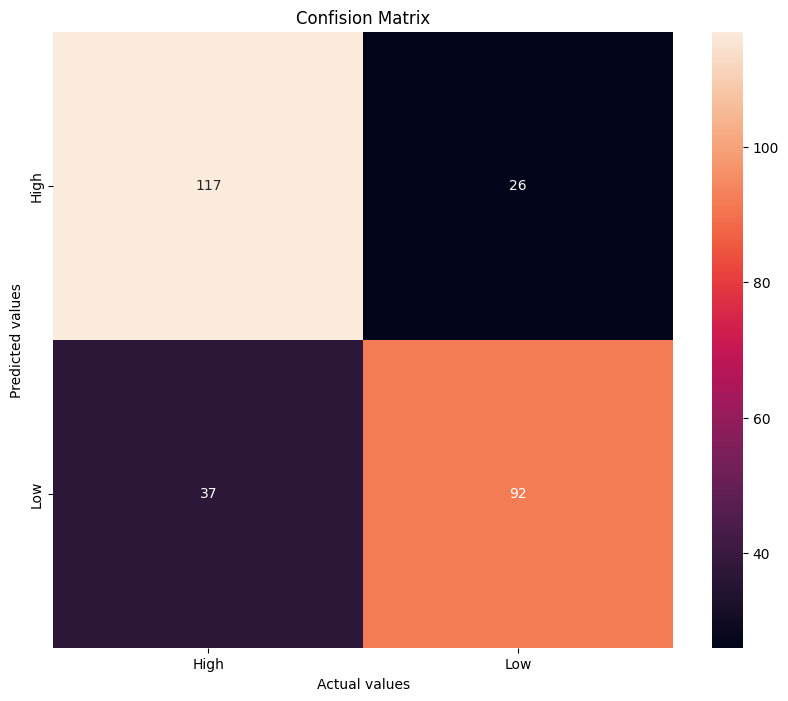

In [ ]:
tp = true_positives
fp =  predictions.filter((predictions.label == 0) & (predictions.prediction == 1)).count()
fn =  predictions.filter((predictions.label == 1) & (predictions.prediction == 0)).count()
tn =  predictions.filter((predictions.label == 0) & (predictions.prediction == 0)).count()
# print(tp)
# print(fp)
# print(fn)
# print(tn)
array = [[tp,fp],[fn,tn]]
df_conf_matrix = pd.DataFrame(array, index = ['High','Low'],
                  columns =  ['High','Low'])
plt.figure(figsize = (10,8))
sns.heatmap(df_conf_matrix, annot = True,fmt="d")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Confision Matrix")
plt.show()

Din matricea de confuzie reiese faptul că:

- 117 de valori au fost prezise ca fiind pozitive, așa cum erau și în mod real
- 26 de valori au fost prezise ca fiind High, deși în mod real sunt Low
- 37 de valori au fost prezise ca fiind Low, deși în mod real sunt High
- 92 de valori au fost prezise ca Low, așa cum erau în mod real.

Vizualizarea influenței caracteristicilor în funcție de coeficienții aflați anterior

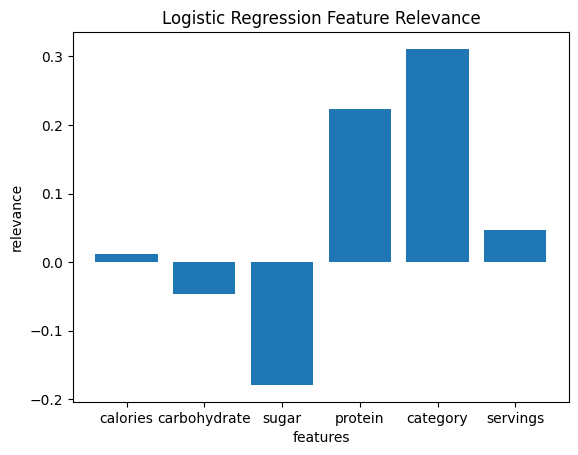

In [ ]:
plt.bar(height=coefs,x=['calories', 'carbohydrate', 'sugar', 'protein', 'category', 'servings'])
plt.title('Logistic Regression Feature Relevance')
plt.xlabel('features')
plt.ylabel('relevance')
plt.show()

Din grafic se poate remarca faptul ca cel mai semnificativ impact asupra variabilei targetate îl are 'category'

## Decision Tree Classifier

Aplicați o metodă de ML prin care să reușiți să obțineți rezultate cât mai bune în ceea ce privește problema de clasificare. Folosiți diverși parametrii și verificați acuratețea și precizia metodei alese.

Al doilea model - arborele de decizie pentru clasificare - a fost ales, pentru că poate modela relații complexe de date, este ușor de interpretat și oferă importanța caracteristicilor.

 Pentru a se obține cel mai bun model de arbore de decizie s-a folosit Grid Search și Cross Validation care au rolul de a ajuta la găsirea celor mai buni parametrii pentru modelul dorit (hyperparameter tuning).

Prin utilizarea Cross Validation se va testa fiecare combinație de parametrii din Grid și ulterior se va putea alege cel mai bun model care are cea mai bună combinație a parametrilor.

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
dtc = DecisionTreeClassifier(labelCol="label", featuresCol="features")

# Hiperparametrii
paramGrid_dtc =ParamGridBuilder().addGrid(dtc.maxDepth, [1, 2, 5, 10]).addGrid(dtc.minInstancesPerNode, [1, 2, 5]).addGrid(dtc.minInfoGain, [0.0, 0.1, 0.2]) \
               .build()

                # adâncimea maximă a arborelui poate preveni overfitting-ul, respectiv underfitting-ul.
                # dtc.maxDepth, [1, 2, 5, 10]

                # numărul minin de instanțe necesare într-un nod pentru a-l împărți în subnoduri
                # creșterea acestui număr împiedică overfittingul și reduce complexitatea arborelui
                # dtc.minInstancesPerNode, [1, 2, 5]

                # valoarea minimă a câștigului de informație pentru a realiza o împărțire a unui nod
                # prin setarea câștigului minim de informații se previn împărțirile care nu aduc un beneficiu semnificativ
                # dtc.minInfoGain, [0.0, 0.1, 0.2]


crossval_dtc = CrossValidator(
                          # modelul care se dorește a fi evaluat și testat prin Cross Validation
                          estimator=dtc,
                          # parametrii pentru care dorim să găsim combinația optimă
                          estimatorParamMaps=paramGrid_dtc,
                          # evaluatorul este BinaryClassificationEvaluator, deoarece este o problemă de clasificare binară, iar metrica utilizată este areaUnderROC
                          # (cu cât valoarea de sub curbă este mai mare, cu atât modelul este considerat mai bun)
                          evaluator=BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC'),
                          # numărul de fold-uri în care va fi împărțit setul de date pentru a se realiza Cross Validation
                          numFolds=5)

# Antrenarea modelului
cvModel_dtc = crossval_dtc.fit(train_data)

# Obținerea celui mai bun model
bestModel_dtc = cvModel_dtc.bestModel

In [ ]:
# Realizarea predicțiilor pe setul de testare
predictions_dtc = bestModel_dtc.transform(test_data)

In [ ]:
# Evaluarea performanței modelului
evaluator_dtc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
roc_auc_dtc = evaluator_dtc.evaluate(predictions_dtc)

# calcularea preciziei = TP/ (TP + FP)
# TP = numărul de preziceri adevărate care în clasa reală erau adevărate
true_positives_dtc = predictions_dtc.filter((predictions_dtc.label == 1) & (predictions_dtc.prediction == 1)).count()
# TP + FP = numărul total de predicții adevărate
predicted_positives_dtc = predictions_dtc.filter(predictions_dtc.prediction == 1).count()
precision_dtc = true_positives_dtc / predicted_positives_dtc if predicted_positives_dtc != 0 else 0

# calcularea acurateții = (TP + TN)/(TP+TN+FP+FN)
# (TP + TN + FP + FN) se poate calcula prin parcurgerea tuturor predicțiilor și numărarea valorilor de 1
total_predictions_dtc = predictions_dtc.count()
# (TP + TN) sunt acele rezultate pentru care răspunsul dat de predicție este același cu cel real.
correct_predictions_dtc = predictions_dtc.filter(col('label') == col('prediction')).count()
accuracy_dtc = correct_predictions_dtc / total_predictions_dtc

# vizualizarea parametrilor optimi ai celui mai bun model
print("Optim parameters: ", bestModel_dtc.extractParamMap())
# afișarea ariei de sub curbă
print("Area Under ROC Curve: ", roc_auc_dtc)

print("Precision: ", precision_dtc)

print("Accuracy: ", accuracy_dtc)

Optim parameters:  {Param(parent='DecisionTreeClassifier_c5471a507689', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'): False, Param(parent='DecisionTreeClassifier_c5471a507689', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext.'): 10, Param(parent='DecisionTreeClassifier_c5471a507689', name='featuresCol', doc='features column name.'): 'features', Param(parent='DecisionTreeClassifier_c5471a507689', name='impurity', doc='Criterion used for information gain calculation (case-insensitive). Supported options: entro

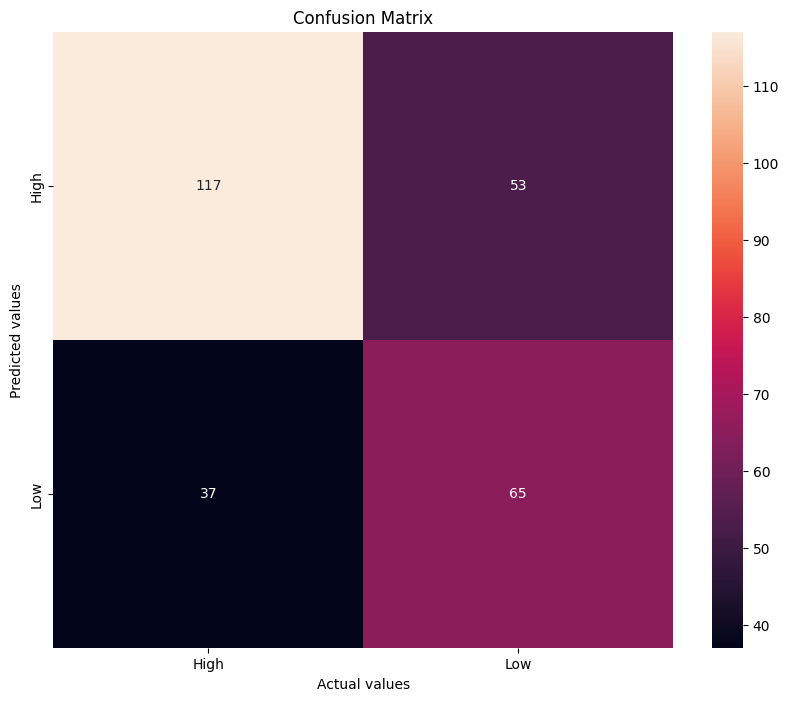

In [ ]:
tp_dtc = true_positives_dtc
fp_dtc =  predictions_dtc.filter((predictions_dtc.label == 0) & (predictions_dtc.prediction == 1)).count()
fn_dtc =  predictions_dtc.filter((predictions_dtc.label == 1) & (predictions_dtc.prediction == 0)).count()
tn_dtc =  predictions_dtc.filter((predictions_dtc.label == 0) & (predictions_dtc.prediction == 0)).count()

array_dtc = [[tp_dtc,fp_dtc],[fn_dtc,tn_dtc]]
df_conf_matrix_dtc = pd.DataFrame(array_dtc, index = ['High','Low'],
                  columns =  ['High','Low'])
plt.figure(figsize = (10,8))
sns.heatmap(df_conf_matrix_dtc, annot = True,fmt="d")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Confusion Matrix")
plt.show()

Din matricea de confuzie reiese faptul că:

- 117 de valori au fost prezise ca fiind pozitive, așa cum erau și în mod real
- 53 de valori au fost prezise ca fiind High, deși în mod real sunt Low
- 37 de valori au fost prezise ca fiind Low, deși în mod real sunt High
- 65 de valori au fost prezise ca Low, așa cum erau în mod real.

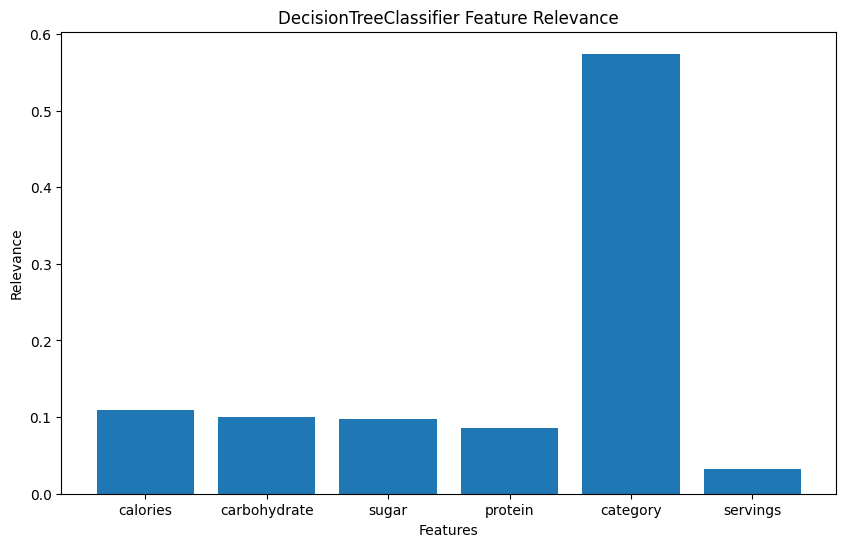

In [ ]:
feature_importances = bestModel_dtc.featureImportances.toArray()

feature_names = ['calories', 'carbohydrate', 'sugar', 'protein', 'category', 'servings']

# Importanța features grafic
plt.figure(figsize=(10, 6))
plt.bar(feature_names, feature_importances)
plt.title('DecisionTreeClassifier Feature Relevance')
plt.xlabel('Features')
plt.ylabel('Relevance')
plt.show()

La fel ca în cazul regresiei logistice, se poate observa că și în cazul arborelui de decizie coloana 'category' este cea care are cel mai mare impact asupra variabilei ținte - 'high_traffic'

# 6. Aplicare DL cu Tenserflow

Folosiți o metodă Deep Learning pentru a aduce încă o soluție problemei de clasificare propuse.

Deep learning folosește rețele neuronale artificiale pentru a putea extrage caracteristici de pe seturi mari de date.

S-a ales crearea unei rețele neuronale care pe ultimul strat folosește o funcție de activare specifică problemelor de clasificare, mai precis - sigmoid. Am ales modelul de rețeaa neuronală NN, deoarece celelalte modele, precum CNN sau RNN erau focalizate pe alte date de input: CNN - în special utilizat pentru lucrul cu imagini, RNN - utilizată pentru limbaje naturale.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout

In [ ]:
model = Sequential()
model.add(Dense(units=64, activation='relu')) # s-a folosit funcția de activare 'relu' care pentru un input negativ întoarce valoarea 0, iar pentru unul pozitiv, propria valoare
                                              # deoarece introduce non-linearitate ceea ce ajută la o generalizare mai bună, și este mai rapid
model.add(Dropout(0.5)) # pentru a preveni overfitting-ul se deconectează 50% din neuroni random pentru a ajuta la o generalizare mai bună
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.5)) # pentru a preveni overfitting-ul se deconectează 50% din neuroni random pentru a ajuta la o generalizare mai bună
model.add(Dense(units=1, activation='sigmoid')) # în final s-a ales funcția de activare sigmoid pentru că aceasta este specifică problemelor de clasificare binară
# având în vedere că aceasta întoarce valori între 0 și 1 care pot fi interpretate ca probabilitatea ca inputul să aparțină uneia dintre clase

# Mai jos este descris procesul de antrenare a modelului de rețea neuronală
# Ca funcție de pierdere (cât de bine prezice modelul etichetele adevărate ale datelor) se folosește 'binary_crossentropy' care este specific problemelor de clasificare binară
# optimizatorul este 'adam', iar evaluarea performanței modelului se face cu metrica - acuratețe (numărul de preziceri corecte raportat la totalul prezicerilor)
model.compile(loss='binary_crossentropy', optimizer='adam',metrics = ['accuracy'])

S-a introdus tehnica EarlyStopping care este folosită pentru a opri antrenarea rețelelor neuronale profunde când nu mai sunt aduse îmbunătățiri pe setul de validare în timpul actualizării parametrilor pentru a nu ajunge la overfitting.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25) #dacă după 25 de epoci consecutive nu mai sunt îmbunătățiri pentru 'val_loss' atunci se va opri antrenarea

Pregătirea datelor pentru a putea fi folosite în antrenarea modelului

In [ ]:
# Convertirea setului de antrenare și testare în format numpy array prin extragerea valorilor din dataFrame
X_train = np.array(train_data.select('features').collect())
y_train = np.array(train_data.select('label').collect())

X_test = np.array(test_data.select('features').collect())
y_test = np.array(test_data.select('label').collect())

# Eliminarea împachetării obiectelor din DataFrame din numpy arrays
X_train = np.array([x[0] for x in X_train])
y_train = np.array([x[0] for x in y_train])
X_test = np.array([x[0] for x in X_test])
y_test = np.array([x[0] for x in y_test])

# Reshape y_train și y_test pentru compabilitatea cu tenserflow ale cărui etichete sunt în formatul bidimensional
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

Antrenarea modelului prin folosirea drept callback a tehnicii de oprire stabilită mai sus.

In [ ]:
history = model.fit(x=X_train,
                   y=y_train,
                   epochs=100,
                   validation_data=(X_test, y_test),
                   verbose=1,
                   callbacks=[early_stop]
                   )

Epoch 1/100
20/20 [==============================] - 2s 41ms/step - loss: 0.7449 - accuracy: 0.5795 - val_loss: 0.6512 - val_accuracy: 0.5625
Epoch 2/100
20/20 [==============================] - 0s 9ms/step - loss: 0.6708 - accuracy: 0.6003 - val_loss: 0.6316 - val_accuracy: 0.6360
Epoch 3/100
20/20 [==============================] - 0s 7ms/step - loss: 0.6579 - accuracy: 0.6116 - val_loss: 0.6306 - val_accuracy: 0.6287
Epoch 4/100
20/20 [==============================] - 0s 10ms/step - loss: 0.6614 - accuracy: 0.6180 - val_loss: 0.6225 - val_accuracy: 0.6838
Epoch 5/100
20/20 [==============================] - 0s 10ms/step - loss: 0.6369 - accuracy: 0.6340 - val_loss: 0.6238 - val_accuracy: 0.6618
Epoch 6/100
20/20 [==============================] - 0s 7ms/step - loss: 0.6342 - accuracy: 0.6292 - val_loss: 0.6230 - val_accuracy: 0.6691
Epoch 7/100
20/20 [==============================] - 0s 9ms/step - loss: 0.6410 - accuracy: 0.6324 - val_loss: 0.6191 - val_accuracy: 0.6985
Epoch 8/10

In [ ]:
print(history.history) # conține măsurătorile de performanță ale modelului în timpul antrenării

print(history.history['val_loss'][:5]) # valori ale funcției de pierdere pe setul de validare
print(history.history['loss'][:5]) # valori ale funcției de pierdere pe setul de antrenare

{'loss': [0.7449371218681335, 0.6707802414894104, 0.657856822013855, 0.6614474058151245, 0.6369470953941345, 0.634162962436676, 0.6409867405891418, 0.6464921832084656, 0.6348411440849304, 0.6029053330421448, 0.6175398230552673, 0.5943276286125183, 0.6038550138473511, 0.5954198241233826, 0.6116469502449036, 0.5840042233467102, 0.5832791924476624, 0.5972693562507629, 0.5942857265472412, 0.5744299292564392, 0.5794855356216431, 0.5961527228355408, 0.5969492197036743, 0.5779241323471069, 0.5902373194694519, 0.5892034769058228, 0.5834544897079468, 0.5719085931777954, 0.583710789680481, 0.5731826424598694, 0.5756861567497253, 0.5822880864143372, 0.5703691244125366, 0.5781445503234863, 0.5870047211647034, 0.565166175365448, 0.5784594416618347, 0.5700308680534363, 0.5731344819068909, 0.5653976202011108, 0.548189640045166, 0.568472146987915, 0.5712829828262329, 0.5728815793991089, 0.5682274699211121, 0.5682626366615295], 'accuracy': [0.579454243183136, 0.6003210544586182, 0.6115570068359375, 0.6

Vizualizarea distribuției funcțiilor de pierdere pentru setul de validare și cel de antrenare

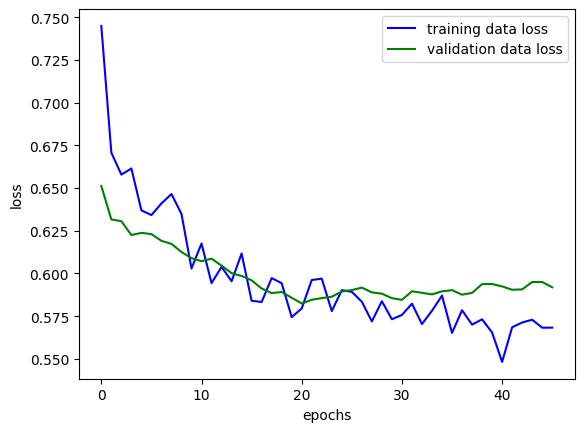

In [ ]:
plt.plot(history.history['loss'], c='blue', label='training data loss')
plt.plot(history.history['val_loss'], c='green', label='validation data loss')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('loss');

Vizualizarea distribuției funcțiilor de acuratețe pentru setul de validare și cel de antrenare

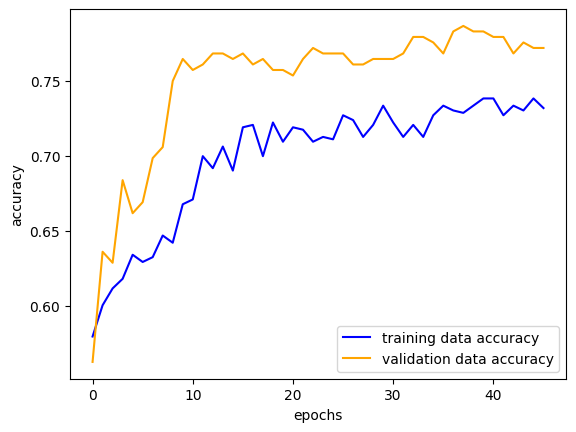

In [ ]:
plt.plot(history.history['accuracy'], c='blue', label='training data accuracy')
plt.plot(history.history['val_accuracy'], c='orange', label='validation data accuracy')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('accuracy');

Evaluarea modelului

Aflarea predicțiilor pe setul de date de test și convertirea în int.

In [ ]:
predictions_dl = (model.predict(X_test) > 0.5).astype(int)

9/9 [==============================] - 0s 3ms/step


Evaluarea modelului prin afișarea loss-ului și a acurateții

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)
print("Test loss: ",test_loss)
print("Accuracy: ", test_accuracy)

9/9 [==============================] - 0s 6ms/step - loss: 0.5919 - accuracy: 0.7721
Test loss:  0.5918900966644287
Accuracy:  0.7720588445663452


Pregătirea metricelor pentru afișarea matricei de confuzie: TP, FP, TN, FN.

In [ ]:
tp_dl = np.sum((predictions_dl == 1) & (y_test == 1))
tn_dl = np.sum((predictions_dl == 0) & (y_test == 0))
fp_dl = np.sum((predictions_dl == 1) & (y_test == 0))
fn_dl = np.sum((predictions_dl == 0) & (y_test == 1))
recall_dl = tp_dl / (tp_dl + fn_dl)

print("True Positives: ",tp_dl)
print("True Negatives: ",tn_dl)
print("False Positives: ",fp_dl)
print("False Negatives: ",fn_dl)
print("Recall: ",recall_dl)

True Positives:  131
True Negatives:  79
False Positives:  39
False Negatives:  23
Recall:  0.8506493506493507


Crearea și afișarea matricei de confuzie.

Confusion Matrix:
[[ 79  39]
 [ 23 131]]


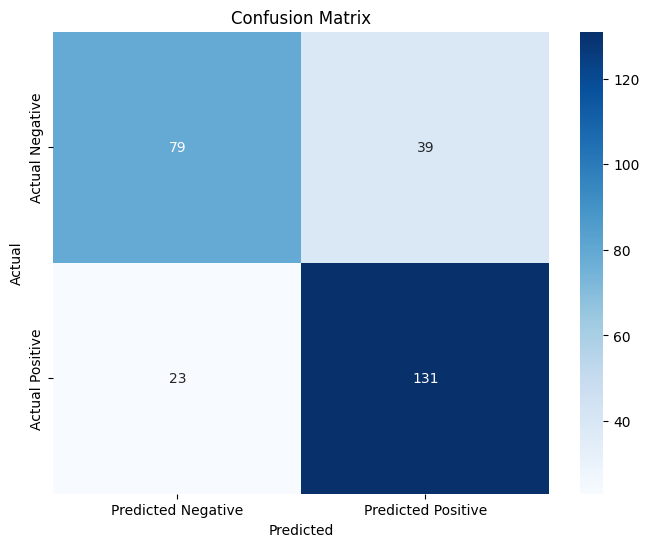

In [ ]:
conf_matrix_dl = np.array([[tn_dl, fp_dl], [fn_dl, tp_dl]])
print("Confusion Matrix:")
print(conf_matrix_dl)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dl, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Negative", "Predicted Positive"], yticklabels=["Actual Negative", "Actual Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Se poate folosi și funcția classification_report. Sunt prezise etichetele clasei pentru datele de testare, iar pentru a le transforma în valori binare se alege comparația cu 0.5, matricea rezultată fiind adusă la o formă unidimensională pentru a putea fi compatibilă comparării cu etichetele reale. Prin aplicarea funcției 'classification_report' se calculează mai multe matrici de evaluare care sunt prezentate mai jos. Aceste matrici oferă o imagine complexă asupra performanței de clasificare.

In [ ]:
from sklearn.metrics import classification_report

y_prediction = (model.predict(X_test) > 0.5).reshape((-1,))
print(classification_report(y_test, y_prediction))

9/9 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.77      0.67      0.72       118
           1       0.77      0.85      0.81       154

    accuracy                           0.77       272
   macro avg       0.77      0.76      0.76       272
weighted avg       0.77      0.77      0.77       272



Din rezultatele evaluării putem trage următoarele concluzii:

1. Precize
- 77% dintre exemplele prezise ca fiind clasa 0 sunt corecte
- 77% dintre exemplele prezise ca fiind clasa 1 sunt corecte

2. Recall (TP/ (TP + FN))
- 67% din toate exemplele reale de clasa 0 au fost prezise corect
- 85% din toate exemplele reale de clasa 1 au fost prezise corect

3. F1-score (cât de bine performează modelul în a face predicții precise pentru fiecare clasă)
- cu cât are o valoare mai mare cu atât modelul este mai bun
- ambele scoruri indică un echilibru între precizie și recall

4. Acuratețea este de 0.77, adică 77% din toate datele au fost prezise corect

5. Macro avg calculează media aritmetică a preciziei, recall și F1-score pentru ambele clase, fiind util pentru a ne face o idee cu privire la performanța medie a modelului pe cele două clase.

6. Weighted avg calculează media ponderată (ține cont de valorile din support) a preciziei, recall și F1-score pentru ambele clase, fiind util pentru o evaluare mai realistă a performanței modelului.

Mai departe se afișează o altă metodă de calculare a matricei de confuzie, la care se adaugă reprezentarea acesteia.

Matrice Confuzie:
[[ 79  39]
 [ 23 131]]


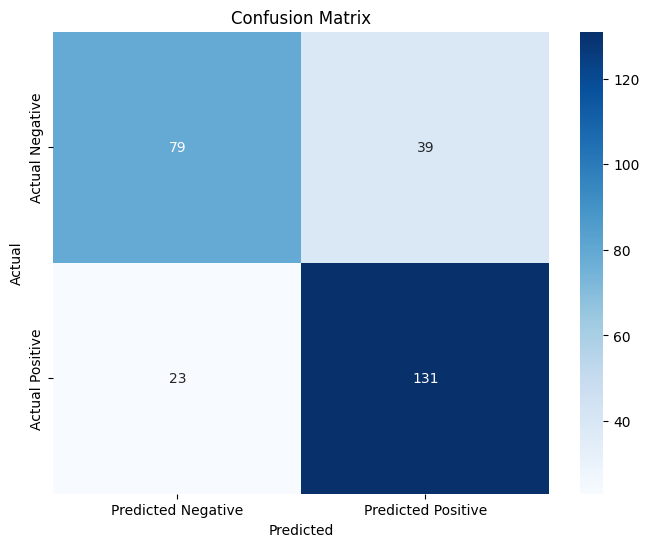

In [ ]:
from sklearn.metrics import confusion_matrix

# Matricea de confuzie
conf_matrix_dl = confusion_matrix(y_test, y_prediction)
print("Matrice Confuzie:")
print(conf_matrix_dl)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dl, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Negative", "Predicted Positive"], yticklabels=["Actual Negative", "Actual Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 7. Spark Streaming

Creați un proces de streaming în care să se folosesască modelele ML antrenate mai sus.

S-a creat un proces de streaming folosind Spark Streaming și s-au aplicat
modelele ML antrenate anterior. S-a realizat stream pe datele care apăreau într-un CSV, urmând ca rezultatele să fie puse într-un alt fișier.

In [ ]:
from pyspark.sql.types import DoubleType
schema_streaming = StructType([
    StructField("servings", IntegerType(), True),
    StructField("label", IntegerType(), True),
    StructField("category", DoubleType(), True),
    StructField("calories", DoubleType(), True),
    StructField("carbohydrate", DoubleType(), True),
    StructField("sugar", DoubleType(), True),
    StructField("protein", DoubleType(), True)
])

# Sample data pentru streaming
data_streaming = [
    (4, 1, 3.0, 35.0, 40.0, 0.5, 1.0),
    (2, 0, 1.0, 250.0, 50.0, 4.0, 120.0),
    (6, 1, 3.0, 10.1, 18.0, 8.50, 11.10),
    (4, 1, 3.0, 574.0,13.0, 1.8, 13.8),
    (2, 1, 9.0, 160.0, 42.0, 1.6, 44.0)
]

# Create DataFrame
df_streaming = spark.createDataFrame(data_streaming, schema_streaming)

# set DataFrame
df_streaming.show()

# Write the DataFrame to a CSV file
df_streaming.write.csv('input_data_streaming.csv', header=True)

+--------+-----+--------+--------+------------+-----+-------+
|servings|label|category|calories|carbohydrate|sugar|protein|
+--------+-----+--------+--------+------------+-----+-------+
|       4|    1|     3.0|    35.0|        40.0|  0.5|    1.0|
|       2|    0|     1.0|   250.0|        50.0|  4.0|  120.0|
|       6|    1|     3.0|    10.1|        18.0|  8.5|   11.1|
|       4|    1|     3.0|   574.0|        13.0|  1.8|   13.8|
|       2|    1|     9.0|   160.0|        42.0|  1.6|   44.0|
+--------+-----+--------+--------+------------+-----+-------+



In [ ]:
streaming_df = spark.readStream.schema(schema_streaming).csv('input_data_streaming.csv')

In [ ]:
from pyspark.ml.feature import VectorAssembler
assembler_streaming = VectorAssembler(inputCols=['calories','carbohydrate','sugar','protein','category','servings'], outputCol='features', handleInvalid='skip')

In [ ]:
streaming_data = assembler_streaming.transform(streaming_df)

## Logistic Regression

In [ ]:
predictions_streaming = bestModel.transform(streaming_data)

In [ ]:
output = predictions_streaming.select('servings', 'category', 'calories','carbohydrate','sugar','protein', 'label', 'prediction')

In [ ]:
output_query = output.writeStream \
    .outputMode("append") \
    .format("csv") \
    .option("path", "predictions_streaming") \
    .option("checkpointLocation", "predictions_checkpoint") \
    .start()

output_query.awaitTermination()

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/usr/local/lib/python3.10/dist-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/usr/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
output_query.stop()

## Decision Tree Classifier

In [ ]:
predictions_streaming_dtc = bestModel_dtc.transform(streaming_data)

In [ ]:
output_dtc = predictions_streaming_dtc.select('servings', 'category', 'calories','carbohydrate','sugar','protein', 'label', 'prediction')

In [ ]:
output_query_dtc = output_dtc.writeStream \
    .outputMode("append") \
    .format("csv") \
    .option("path", "predictions_streaming_dtc") \
    .option("checkpointLocation", "predictions_checkpoint_dtc") \
    .start()

output_query_dtc.awaitTermination()

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/usr/local/lib/python3.10/dist-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/usr/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
output_query_dtc.stop()

In [ ]:
sc.stop()